# 02 — PROSPECCTS benchmark: compare PocketVec / NRGRank / DrugCLIP / EPoCS

Refactor of `compute_NRGRank_descriptors.ipynb` with EPoCS added as a fourth method. Produces `out_prospeccts_dfs_dict[D-key]`: one pandas DataFrame per PROSPECCTS dataset with `p1, p2, lab` and one distance + one score column per method.

**Methods and metrics**

| method | descriptor | distance | score (used for ROC) |
|---|---|---|---|
| PocketVec | rank-vec, 128 ints | cosine | `1 - cosdist` |
| NRGRank | rank-vec, dataset-sized ints | cosine | `1 - cosdist` |
| DrugCLIP (variants) | precomputed pickles | cosine | `1 - cosdist` |
| **EPoCS** | mean-pooled ESM-2 embedding, 2560 floats | **Euclidean** (per Oruc et al.) | `-eucdist` (rank-preserving) |

**Run order:** run [`01_compute_EPoCS_distances.ipynb`](01_compute_EPoCS_distances.ipynb) first to populate `DATA/epocs_eucdist/`.

**Kernel:** `Python [conda env:pocketeer-env]` (numpy 2.x for the EPoCS pickles).

In [1]:
import os
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
pd.set_option('future.infer_string', False)  # keep plain object dtype for strings - see normalize_pair_dtypes below
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

BENCHMARK_DIR = Path.cwd().parent / 'DATA' / 'pocket_benchmark'
DATA_DIR     = BENCHMARK_DIR / 'DATA'
PAIRS_DIR    = DATA_DIR / 'PROSPECCTS_pairs'
POCKETVEC_DIR= DATA_DIR / 'pocketvec_descriptors'
NRGRANK_DIR  = DATA_DIR / 'NRGRank_results'
DRUGCLIP_DIR = DATA_DIR / 'drugclip_cosdist'
EPOCS_DIR    = DATA_DIR / 'epocs_eucdist'


def save_pickle(obj, path: Path) -> None:
    with open(path, 'wb') as f:
        pickle.dump(obj, f)


def load_pickle(path: Path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def normalize_pair_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Force p1/p2/lab, and the column index itself, to plain object dtype
    before pickling.

    pandas >= 3.0 defaults to inferring a StringDtype for string columns AND
    for the column Index (`pd.options.future.infer_string`), which older
    pandas installs can't unpickle (NotImplementedError on load). Casting
    back to classic object dtype keeps every saved .pkl loadable regardless
    of which pandas wrote or reads it.
    """
    df = df.copy()
    df.columns = pd.Index([str(c) for c in df.columns], dtype=object)
    for col in ('p1', 'p2', 'lab'):
        if col in df.columns:
            df[col] = df[col].astype(object)
    return df


def cosine_distance(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> float:
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    return 1.0 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + eps)

## 1. Dataset configuration

Single source of truth: each PROSPECCTS dataset (D-key) maps to one pair-list CSV, one PocketVec descriptor pickle, one NRGRank results subdir, and one EPoCS distance pickle. DrugCLIP variants are matched by filename pattern.

In [2]:
DATASETS = {
    'D1':   {'pretty': 'identical_structures',                'pair_csv': 'identical_structures.csv',                'nrgrank_subdir': 'identical_structures',                'epocs_name': 'identical_structures'},
    'D1.2': {'pretty': 'identical_structures_similar_ligands','pair_csv': 'identical_structures_similar_ligands.csv','nrgrank_subdir': 'identical_structures_similar_ligands','epocs_name': 'identical_structures_similar_ligands'},
    'D2':   {'pretty': 'NMR_structures',                      'pair_csv': 'NMR_structures.csv',                      'nrgrank_subdir': 'NMR_structures',                      'epocs_name': 'NMR_structures'},
    'D3':   {'pretty': 'decoy_rational_structures',           'pair_csv': 'decoy_structures.csv',                    'nrgrank_subdir': 'decoy_rational_structures',           'epocs_name': 'decoy_rational'},
    'D4':   {'pretty': 'decoy_shape_structures',              'pair_csv': 'decoy_structures.csv',                    'nrgrank_subdir': 'decoy_shape_structures',              'epocs_name': 'decoy_shape'},
    'D5':   {'pretty': 'kahraman_80 (no phosphates)',         'pair_csv': 'kahraman_structures.csv',                 'nrgrank_subdir': 'kahraman_structures',                 'epocs_name': 'kahraman_structures'},
    'D5.2': {'pretty': 'kahraman_100 (full)',                 'pair_csv': 'kahraman_structures.csv',                 'nrgrank_subdir': 'kahraman_structures',                 'epocs_name': 'kahraman_structures'},
    'D6':   {'pretty': 'barelier_structures',                 'pair_csv': 'barelier_structures.csv',                 'nrgrank_subdir': 'barelier_structures',                 'epocs_name': 'barelier_structures'},
    'D7':   {'pretty': 'review_structures',                   'pair_csv': 'review_structures.csv',                   'nrgrank_subdir': 'review_structures',                   'epocs_name': 'review_structures'},
}

DKEYS = list(DATASETS.keys())

## 2. Load PROSPECCTS pair lists

In [3]:
def load_pair_list(csv_name: str) -> pd.DataFrame:
    df = pd.read_csv(PAIRS_DIR / csv_name, header=None, names=['p1', 'p2', 'lab'])
    return normalize_pair_dtypes(df)

out = {dkey: load_pair_list(cfg['pair_csv']) for dkey, cfg in DATASETS.items()}
pd.DataFrame({k: [len(df), df['lab'].value_counts().to_dict()] for k, df in out.items()},
             index=['n_pairs', 'lab_counts']).T

,n_pairs,lab_counts
D1,106276,"{'inactive': 92846, 'active': 13430}"
D1.2,2025,"{'inactive': 1784, 'active': 241}"
D2,108241,"{'inactive': 100512, 'active': 7729}"
D3,80580,"{'inactive': 67150, 'active': 13430}"
D4,80580,"{'inactive': 67150, 'active': 13430}"
D5,10000,"{'inactive': 8680, 'active': 1320}"
D5.2,10000,"{'inactive': 8680, 'active': 1320}"
D6,62,"{'inactive': 43, 'active': 19}"
D7,56399,"{'inactive': 56284, 'active': 115}"


In [4]:
19/62

0.3064516129032258

In [5]:
out['D6']

,p1,p2,lab
0,1eyn,1ow4,active
1,2ans,1eyn,active
2,2ans,1ow4,active
3,3fty,1w7h,active
4,1vyg,1diy,active
...,...,...,...
57,1s2c,2pix,inactive
58,2p1q,2oyf,inactive
59,2p1q,4hm0,inactive
60,1s4m,1he5,inactive


## 3. PocketVec — cosine distance over rank vectors

In [6]:
pocketvec = {}
for dkey in DKEYS:
    p = POCKETVEC_DIR / f'{dkey}.pkl'
    if p.is_file():
        pocketvec[dkey] = load_pickle(p)
    else:
        print(f'  no PocketVec descriptor for {dkey} — column will be all NaN')
        pocketvec[dkey] = {}


def attach_pairwise_cosdist(df: pd.DataFrame, descriptors: dict, col: str) -> pd.DataFrame:
    dists = []
    for p1, p2 in zip(df['p1'].astype(str), df['p2'].astype(str)):
        a, b = descriptors.get(p1), descriptors.get(p2)
        dists.append(cosine_distance(a, b) if a is not None and b is not None else np.nan)
    df[col] = dists
    return df

for dkey in DKEYS:
    attach_pairwise_cosdist(out[dkey], pocketvec[dkey], 'pocketvec_cosdist')

{k: out[k]['pocketvec_cosdist'].notna().sum() for k in DKEYS}

{'D1': np.int64(106276),
 'D1.2': np.int64(2025),
 'D2': np.int64(108241),
 'D3': np.int64(80580),
 'D4': np.int64(80580),
 'D5': np.int64(6400),
 'D5.2': np.int64(10000),
 'D6': np.int64(62),
 'D7': np.int64(56399)}

## 4. NRGRank — build rank-vector descriptors then cosine distance

Each `target.csv` lists `Score` for `POCKETVEC_LLM_<i>` probes. We sort ascending by Score (most negative = best fit), then build a rank vector where `vec[i-1]` = the rank position (1-indexed) of probe `POCKETVEC_LLM_i`. Cosine distance is then computed between rank vectors.

In [7]:
PROBE_RE = re.compile(r'POCKETVEC_LLM_(\d+)')
# Precomputed rank-vector descriptors (see 03_compute_descriptors.ipynb) - use
# these when NRGRank_results itself isn't reachable (e.g. it lived on a network
# mount / other machine that's since gone away). Falls back to rebuilding from
# the raw target.csv files when there's no cache for a given dataset.
NRGRANK_CACHE_DIR = DATA_DIR / 'nrgrank_descriptors'


def build_nrgrank_descriptor(target_csv: Path) -> np.ndarray:
    df = pd.read_csv(target_csv)
    sorted_df = df.sort_values('Score', ascending=True).reset_index(drop=True)
    probe_ids = sorted_df['Name'].str.extract(PROBE_RE, expand=False).astype(int).to_numpy()
    rank_vec = np.empty(len(df), dtype=int)
    rank_vec[probe_ids - 1] = np.arange(len(probe_ids))
    return rank_vec + 1  # 1-indexed


def build_all_nrgrank_descriptors(dataset_subdir: str) -> dict:
    ds_root = NRGRANK_DIR / dataset_subdir
    out = {}
    for protein_dir in sorted(ds_root.iterdir()):
        target = protein_dir / 'target.csv'
        if not target.is_file():
            continue
        try:
            out[protein_dir.name] = build_nrgrank_descriptor(target)
        except Exception as e:
            print(f'  skipped {protein_dir.name}: {e}')
    return out


nrgrank = {}
for dkey, cfg in DATASETS.items():
    cache_path = NRGRANK_CACHE_DIR / f'{dkey}.pkl'
    if cache_path.is_file():
        print(f'  loading NRGRank: {dkey} (cached -> {cache_path.name})')
        nrgrank[dkey] = load_pickle(cache_path)
    else:
        print(f'  loading NRGRank: {dkey} (rebuilding from {NRGRANK_DIR / cfg["nrgrank_subdir"]})')
        nrgrank[dkey] = build_all_nrgrank_descriptors(cfg['nrgrank_subdir'])

for dkey in DKEYS:
    attach_pairwise_cosdist(out[dkey], nrgrank[dkey], 'nrgrank_cosdist')

{k: out[k]['nrgrank_cosdist'].notna().sum() for k in DKEYS}

  loading NRGRank: D1 (cached -> D1.pkl)
  loading NRGRank: D1.2 (cached -> D1.2.pkl)
  loading NRGRank: D2 (cached -> D2.pkl)
  loading NRGRank: D3 (cached -> D3.pkl)
  loading NRGRank: D4 (cached -> D4.pkl)
  loading NRGRank: D5 (cached -> D5.pkl)
  loading NRGRank: D5.2 (cached -> D5.2.pkl)
  loading NRGRank: D6 (cached -> D6.pkl)
  loading NRGRank: D7 (cached -> D7.pkl)


{'D1': np.int64(104976),
 'D1.2': np.int64(2025),
 'D2': np.int64(108241),
 'D3': np.int64(79702),
 'D4': np.int64(79702),
 'D5': np.int64(10000),
 'D5.2': np.int64(10000),
 'D6': np.int64(62),
 'D7': np.int64(56350)}

## 5. DrugCLIP — load precomputed `(p1, p2) -> cosdist` pickles

Expected filenames: `prospeccts-<dataset>-drugclip[*]_cosdist.pkl`. Variants are kept as separate columns. Recognised metric tails:

- `drugclip_cosdist` — basic cosine distance from DrugCLIP embeddings
- `drugclip_screening_cosvec_cosdist` (alias `drugclip_cosvec`)
- `drugclip_screening_rankvec_cosdist` (alias `drugclip_rankvec`)
- `12A512atoms` variant — surface-truncated re-embedding

In [8]:
DRUGCLIP_METRIC_ALIAS = {
    'drugclip_cosdist':                    'drugclip_cosdist',
    'drugclip_screening_cosvec_cosdist':   'drugclip_cosvec_cosdist',
    'drugclip_screening_rankvec_cosdist':  'drugclip_rankvec_cosdist',
}

PROSPECCTS_NAME_TO_DKEY = {cfg['epocs_name']: dkey for dkey, cfg in DATASETS.items()}
# kahraman_structures pickles cover the full 100-protein set, so route them to D5.2;
# D5 (80 proteins, no phosphates) is later derived by filtering D5.2.
PROSPECCTS_NAME_TO_DKEY.update({
    'identical_structures': 'D1',
    'identical_structures_similar_ligands': 'D1.2',
    'NMR_structures': 'D2',
    'decoy_rational': 'D3',
    'decoy_shape': 'D4',
    'kahraman_structures': 'D5.2',
    'barelier_structures': 'D6',
    'review_structures': 'D7',
})

DRUGCLIP_FNAME_RE = re.compile(r'^prospeccts-(?P<dataset>.+?)(?P<surf>_12A512atoms)?-(?P<metric>drugclip[\w]*_cosdist)\.pkl$')


def attach_drugclip(out: dict, drugclip_dir: Path, verbose: bool = True) -> list:
    """Walk drugclip_dir, attach every recognised cosdist file as a new column."""
    loaded = []
    for fname in sorted(os.listdir(drugclip_dir)):
        m = DRUGCLIP_FNAME_RE.match(fname)
        if not m:
            continue
        metric = m.group('metric')
        if metric not in DRUGCLIP_METRIC_ALIAS:
            continue
        ds_name = m.group('dataset')
        surf_tag = m.group('surf') or ''
        dkey = PROSPECCTS_NAME_TO_DKEY.get(ds_name)
        if dkey is None or dkey not in out:
            if verbose: print(f'  skip {fname}: dataset "{ds_name}" not mapped')
            continue
        col = DRUGCLIP_METRIC_ALIAS[metric] + ('_12A512atoms' if surf_tag else '')
        cosdist = load_pickle(drugclip_dir / fname)
        df = out[dkey]
        df[col] = [cosdist.get((p1, p2), np.nan) for p1, p2 in zip(df['p1'], df['p2'])]
        loaded.append((fname, dkey, col))
        if verbose: print(f'  {fname} -> {dkey}.{col}')
    return loaded

_ = attach_drugclip(out, DRUGCLIP_DIR, verbose=True)

  prospeccts-NMR_structures-drugclip_cosdist.pkl -> D2.drugclip_cosdist
  prospeccts-NMR_structures-drugclip_screening_cosvec_cosdist.pkl -> D2.drugclip_cosvec_cosdist
  prospeccts-NMR_structures-drugclip_screening_rankvec_cosdist.pkl -> D2.drugclip_rankvec_cosdist
  prospeccts-NMR_structures_12A512atoms-drugclip_cosdist.pkl -> D2.drugclip_cosdist_12A512atoms
  prospeccts-barelier_structures-drugclip_cosdist.pkl -> D6.drugclip_cosdist


  prospeccts-barelier_structures-drugclip_screening_cosvec_cosdist.pkl -> D6.drugclip_cosvec_cosdist
  prospeccts-barelier_structures-drugclip_screening_rankvec_cosdist.pkl -> D6.drugclip_rankvec_cosdist
  prospeccts-barelier_structures_12A512atoms-drugclip_cosdist.pkl -> D6.drugclip_cosdist_12A512atoms
  skip prospeccts-barelier_structures_cofactors-drugclip_cosdist.pkl: dataset "barelier_structures_cofactors" not mapped
  skip prospeccts-barelier_structures_cofactors-drugclip_screening_cosvec_cosdist.pkl: dataset "barelier_structures_cofactors" not mapped
  skip prospeccts-barelier_structures_cofactors-drugclip_screening_rankvec_cosdist.pkl: dataset "barelier_structures_cofactors" not mapped


  prospeccts-decoy_rational-drugclip_cosdist.pkl -> D3.drugclip_cosdist


  prospeccts-decoy_rational-drugclip_screening_cosvec_cosdist.pkl -> D3.drugclip_cosvec_cosdist


  prospeccts-decoy_rational-drugclip_screening_rankvec_cosdist.pkl -> D3.drugclip_rankvec_cosdist


...

  prospeccts-decoy_shape-drugclip_screening_rankvec_cosdist.pkl -> D4.drugclip_rankvec_cosdist


  prospeccts-decoy_shape_12A512atoms-drugclip_cosdist.pkl -> D4.drugclip_cosdist_12A512atoms
  prospeccts-identical_structures-drugclip_cosdist.pkl -> D1.drugclip_cosdist
  prospeccts-identical_structures-drugclip_screening_cosvec_cosdist.pkl -> D1.drugclip_cosvec_cosdist


  prospeccts-identical_structures-drugclip_screening_rankvec_cosdist.pkl -> D1.drugclip_rankvec_cosdist
  prospeccts-identical_structures_12A512atoms-drugclip_cosdist.pkl -> D1.drugclip_cosdist_12A512atoms
  prospeccts-identical_structures_similar_ligands-drugclip_cosdist.pkl -> D1.2.drugclip_cosdist
  prospeccts-identical_structures_similar_ligands-drugclip_screening_cosvec_cosdist.pkl -> D1.2.drugclip_cosvec_cosdist
  prospeccts-identical_structures_similar_ligands-drugclip_screening_rankvec_cosdist.pkl -> D1.2.drugclip_rankvec_cosdist
  prospeccts-identical_structures_similar_ligands_12A512atoms-drugclip_cosdist.pkl -> D1.2.drugclip_cosdist_12A512atoms
  prospeccts-kahraman_structures-drugclip_cosdist.pkl -> D5.2.drugclip_cosdist
  prospeccts-kahraman_structures-drugclip_screening_cosvec_cosdist.pkl -> D5.2.drugclip_cosvec_cosdist
  prospeccts-kahraman_structures-drugclip_screening_rankvec_cosdist.pkl -> D5.2.drugclip_rankvec_cosdist
  prospeccts-kahraman_structures_12A512atoms-drug

  prospeccts-review_structures-drugclip_cosdist.pkl -> D7.drugclip_cosdist
  prospeccts-review_structures-drugclip_screening_cosvec_cosdist.pkl -> D7.drugclip_cosvec_cosdist


  prospeccts-review_structures-drugclip_screening_rankvec_cosdist.pkl -> D7.drugclip_rankvec_cosdist
  prospeccts-review_structures_12A512atoms-drugclip_cosdist.pkl -> D7.drugclip_cosdist_12A512atoms


## 6. EPoCS — Euclidean distance from `01_*` output

Smaller distance ⇒ more similar. We carry the raw distance and compute a rank-preserving score (`-eucdist`) for ROC.

In [9]:
def attach_epocs(out: dict, epocs_dir: Path) -> None:
    for dkey, cfg in DATASETS.items():
        path = epocs_dir / f'prospeccts-{cfg["epocs_name"]}-epocs_eucdist.pkl'
        if not path.is_file():
            print(f'  skip {dkey}: no file {path.name}')
            continue
        eucdist = load_pickle(path)
        df = out[dkey]
        df['epocs_eucdist'] = [eucdist.get((p1, p2), np.nan) for p1, p2 in zip(df['p1'], df['p2'])]
        n_filled = df['epocs_eucdist'].notna().sum()
        print(f'  {dkey}: {n_filled}/{len(df)} pairs filled')

attach_epocs(out, EPOCS_DIR)

  D1: 106276/106276 pairs filled
  D1.2: 2025/2025 pairs filled
  D2: 108241/108241 pairs filled


  D3: 80580/80580 pairs filled


  D4: 80580/80580 pairs filled
  D5: 10000/10000 pairs filled
  D5.2: 10000/10000 pairs filled
  D6: 62/62 pairs filled


  D7: 56203/56399 pairs filled


## 6b. Derive D5 (kahraman_80) from D5.2 (kahraman_100)

D5 is the kahraman 80-protein subset that excludes the 20 phosphate complexes. The exclusion list is taken from the difference between PocketVec D5.2 (100) and D5 (80) descriptors — verified to be a strict subset with identical descriptors for the 80 shared proteins. Filtering D5.2 propagates whatever methods D5.2 has (PocketVec, NRGRank, DrugCLIP, EPoCS) into D5 in one step, instead of re-loading from per-method D5 sources.

In [10]:
d5_excluded = (set(load_pickle(POCKETVEC_DIR / 'D5.2.pkl').keys())
               - set(load_pickle(POCKETVEC_DIR / 'D5.pkl').keys()))
print(f'{len(d5_excluded)} phosphate proteins excluded from D5: {sorted(d5_excluded)}')

mask = ~out['D5.2']['p1'].isin(d5_excluded) & ~out['D5.2']['p2'].isin(d5_excluded)
out['D5'] = out['D5.2'].loc[mask].reset_index(drop=True)
print(f'D5 = D5.2 filtered: {len(out["D5"])}/{len(out["D5.2"])} pairs kept')

20 phosphate proteins excluded from D5: ['1a6qA', '1b8oA', '1brwA', '1cqjB', '1d1qB', '1dakA', '1e9gA', '1ejdB', '1eucA', '1ew2A', '1fbtB', '1gypA', '1h6lA', '1ho5B', '1l5wB', '1l7mA', '1lbyA', '1lyvA', '1qf5A', '1tcoA']
D5 = D5.2 filtered: 6400/10000 pairs kept


## 7. Convert distances to scores

All scores are oriented so **higher = more similar = more likely active**. Cosine: `1 - cosdist`. Euclidean: `-eucdist` (rank-preserving).

In [11]:
COSDIST_COLS = [
    'pocketvec_cosdist', 'nrgrank_cosdist',
    'drugclip_cosdist', 'drugclip_cosdist_12A512atoms',
    'drugclip_cosvec_cosdist', 'drugclip_rankvec_cosdist',
]
EUCDIST_COLS = ['epocs_eucdist']

for dkey, df in out.items():
    for c in COSDIST_COLS:
        if c in df.columns:
            df[c.replace('_cosdist', '_score')] = 1.0 - pd.to_numeric(df[c], errors='coerce')
    for c in EUCDIST_COLS:
        if c in df.columns:
            df[c.replace('_eucdist', '_score')] = -pd.to_numeric(df[c], errors='coerce')

# show a sample
out['D2'].head()

,p1,p2,lab,pocketvec_cosdist,nrgrank_cosdist,drugclip_cosdist,drugclip_cosvec_cosdist,drugclip_rankvec_cosdist,drugclip_cosdist_12A512atoms,epocs_eucdist,pocketvec_score,nrgrank_score,drugclip_score,drugclip_score_12A512atoms,drugclip_cosvec_score,drugclip_rankvec_score,epocs_score
0,cz00A,cz00A,active,-2.220446e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-0.000000
1,cz00A,cz01A,active,2.302850e-02,0.020280,0.011911,0.008522,0.002114,0.002453,0.000000,0.976972,0.979720,0.988089,0.997547,0.991478,0.997886,-0.000000
2,cz00A,cz02A,active,9.885470e-02,0.029785,0.095051,0.058962,0.017358,0.144646,0.673121,0.901145,0.970215,0.904949,0.855354,0.941038,0.982642,-0.673121
3,cz00A,cz03A,active,6.308073e-02,0.069124,0.074452,0.054535,0.008841,0.075605,0.531846,0.936919,0.930876,0.925548,0.924395,0.945465,0.991159,-0.531846
4,cz00A,cz04A,active,2.511165e-01,0.065851,0.111280,0.212358,0.031346,0.084944,0.564694,0.748884,0.934149,0.888720,0.915056,0.787642,0.968654,-0.564694


## 8. Save the consolidated dataframes

In [12]:
RESULTS_DIR = BENCHMARK_DIR / 'RESULTS'
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
out = {k: normalize_pair_dtypes(v) for k, v in out.items()}
save_pickle(out, RESULTS_DIR / 'prospeccts_benchmark_dfs.pkl')
print(f'Saved -> {RESULTS_DIR / "prospeccts_benchmark_dfs.pkl"}')

Saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_benchmark_dfs.pkl


## 8b. Attach naive/baseline scores

Four reference baselines computed in `04_naive_baselines.ipynb` (same p1/p2/lab pairs per dataset): `same_protein`, `same_ligand`, `pocket_seqid`, `ligand_tanimoto`. Kept as a separate, fast-to-rebuild artifact so this notebook doesn't need to redo the RCSB round-trip / global-alignment work on every run - this cell just joins them in by (p1, p2).

In [13]:
BASELINE_PKL = RESULTS_DIR / 'prospeccts_naive_baseline_dfs.pkl'
BASELINE_COLS = ['same_protein_score', 'same_ligand_score', 'pocket_seqid_score', 'ligand_tanimoto_score']

if BASELINE_PKL.is_file():
    baselines = load_pickle(BASELINE_PKL)
    for dkey in out:
        if dkey not in baselines:
            print(f'  no baseline rows for {dkey}, skipping')
            continue
        b = baselines[dkey].set_index(['p1', 'p2'])[BASELINE_COLS]
        out[dkey] = (out[dkey]
                     .drop(columns=[c for c in BASELINE_COLS if c in out[dkey].columns])
                     .join(b, on=['p1', 'p2']))
        # derived "distance" versions of the two continuous baselines, for the
        # active-vs-inactive distribution plots in section 12
        out[dkey]['pocket_seqid_dist'] = 1.0 - pd.to_numeric(out[dkey]['pocket_seqid_score'], errors='coerce')
        out[dkey]['ligand_tanimoto_dist'] = 1.0 - pd.to_numeric(out[dkey]['ligand_tanimoto_score'], errors='coerce')

    out = {k: normalize_pair_dtypes(v) for k, v in out.items()}
    save_pickle(out, RESULTS_DIR / 'prospeccts_benchmark_dfs.pkl')
    print(f'Attached naive baselines from {BASELINE_PKL.name}; re-saved -> prospeccts_benchmark_dfs.pkl')
else:
    print(f'No baseline pickle at {BASELINE_PKL} - run 04_naive_baselines.ipynb first. Skipping attach.')

Attached naive baselines from prospeccts_naive_baseline_dfs.pkl; re-saved -> prospeccts_benchmark_dfs.pkl


## 8c. Restrict D3/D4 to the five-residue-variant decoy subset

The raw `decoy_structures.csv` pools all five mutation levels (1-5 mutated binding-site residues per decoy) into one file - 13,430 active / 67,150 inactive raw rows. The ProSPECCTS / PocketVec papers instead score against only the **five-mutation** decoys (13,430 / 13,430 - see their published table). Decoy ids encode the level directly (`<group><level><index><chain>`, e.g. `A500A` = group A, level 5, index 00) - verified directly against the structure files: `A1xxA` decoys differ from their group's wild-type sequence by exactly 1 residue, `A2xxA` by exactly 2, ... `A5xxA` by exactly 5. `active` (real-vs-real) rows are untouched; only `inactive` (real-vs-decoy) rows are restricted to level 5.

In [14]:
import re

FIVE_MUTATION_DECOY_RE = re.compile(r'^[A-Za-z]5\d{2}[A-Za-z]?$')


def restrict_to_five_mutation_decoys(df: pd.DataFrame) -> pd.DataFrame:
    """Keep every 'active' (real-vs-real) row; keep an 'inactive' (real-vs-decoy)
    row only if the decoy (p2) is a five-mutated-residue variant."""
    is_active = df['lab'] == 'active'
    is_level5 = df['p2'].astype(str).str.match(FIVE_MUTATION_DECOY_RE)
    return df[is_active | is_level5].reset_index(drop=True)


for dkey in ('D3', 'D4'):
    before = len(out[dkey])
    before_active = int((out[dkey]['lab'] == 'active').sum())
    before_inactive = int((out[dkey]['lab'] == 'inactive').sum())
    out[dkey] = restrict_to_five_mutation_decoys(out[dkey])
    after_active = int((out[dkey]['lab'] == 'active').sum())
    after_inactive = int((out[dkey]['lab'] == 'inactive').sum())
    print(f'{dkey}: {before} -> {len(out[dkey])} rows '
          f'(active {before_active} -> {after_active}, inactive {before_inactive} -> {after_inactive})')

out = {k: normalize_pair_dtypes(v) for k, v in out.items()}
save_pickle(out, RESULTS_DIR / 'prospeccts_benchmark_dfs.pkl')
print(f'Re-saved -> {RESULTS_DIR / "prospeccts_benchmark_dfs.pkl"}')

D3: 80580 -> 26860 rows (active 13430 -> 13430, inactive 67150 -> 13430)


D4: 80580 -> 26860 rows (active 13430 -> 13430, inactive 67150 -> 13430)
Re-saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_benchmark_dfs.pkl


## 9. ROC comparison per dataset

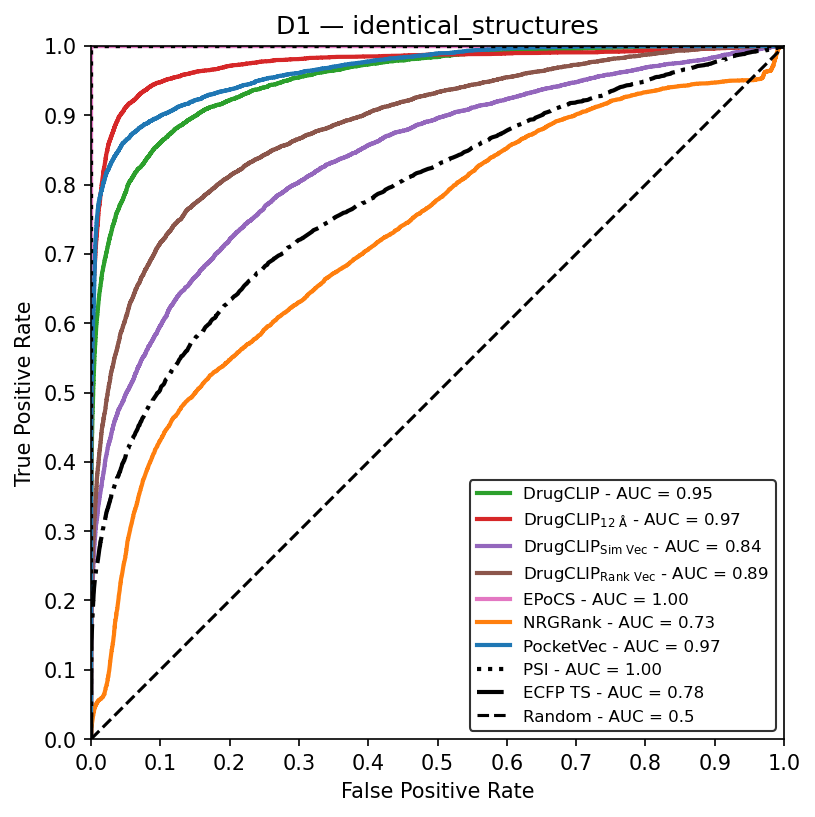

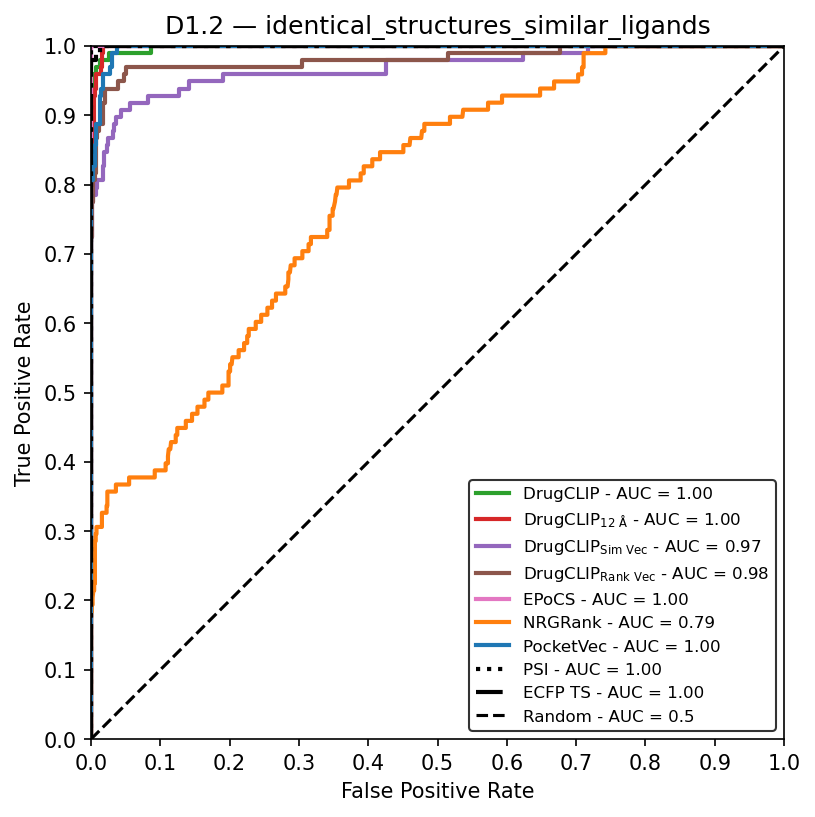

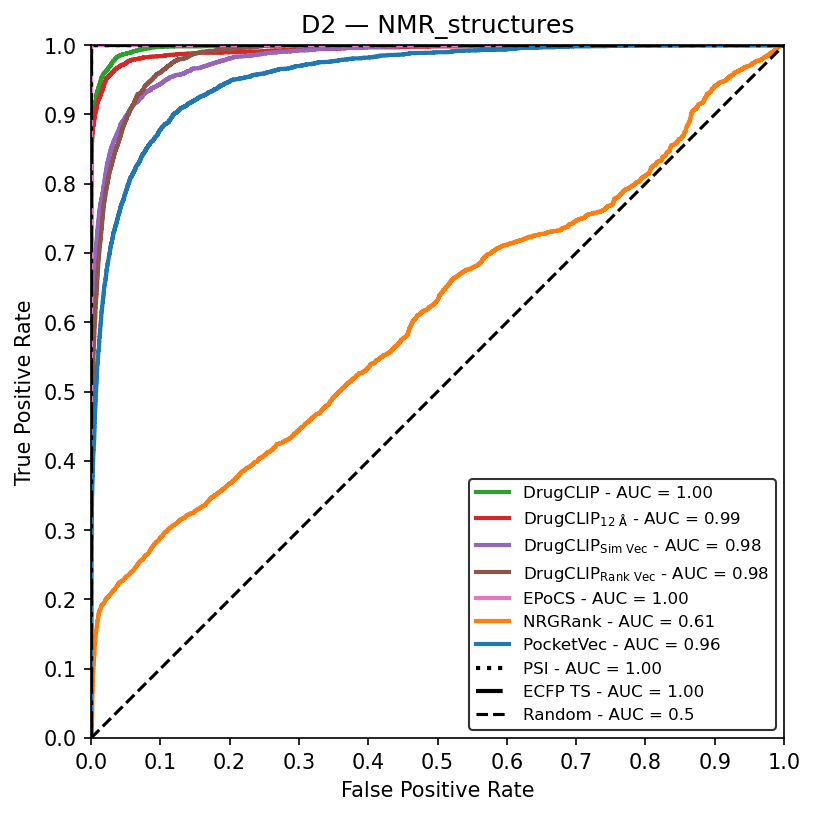

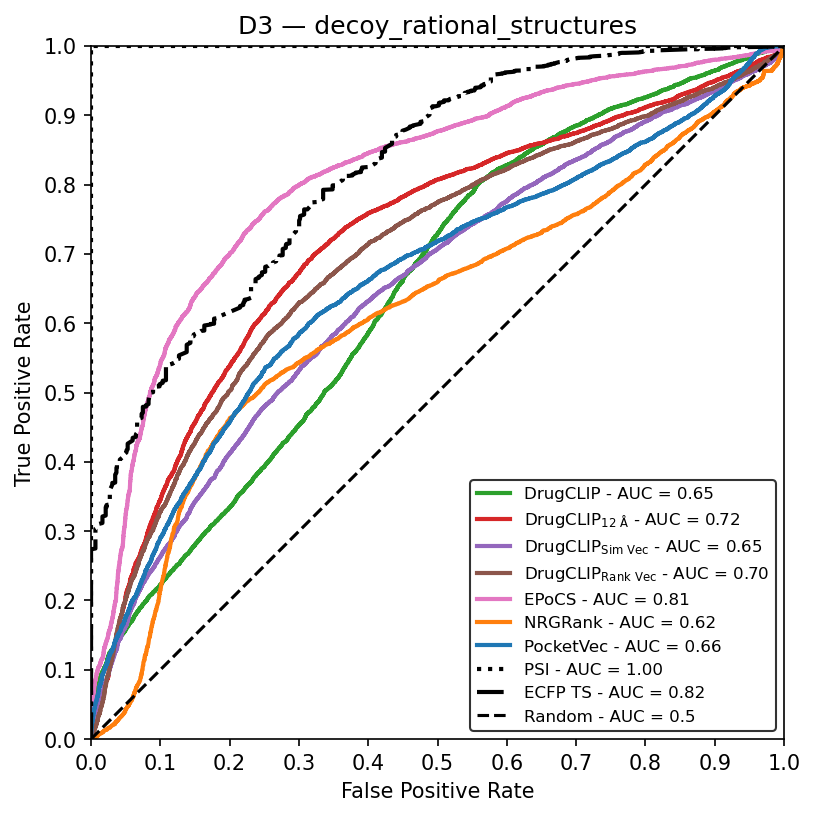

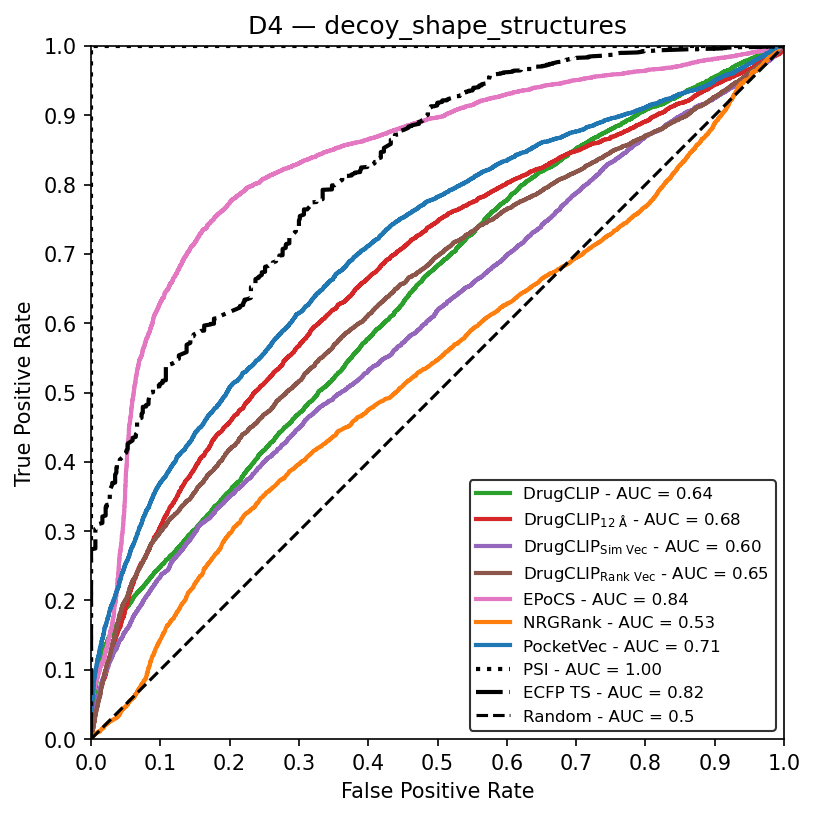

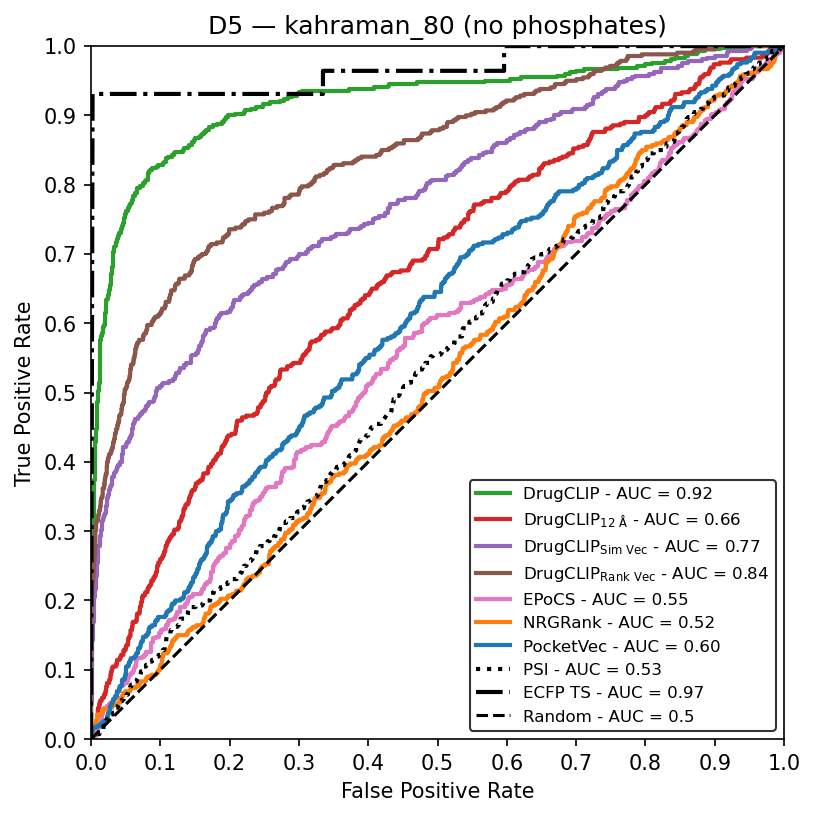

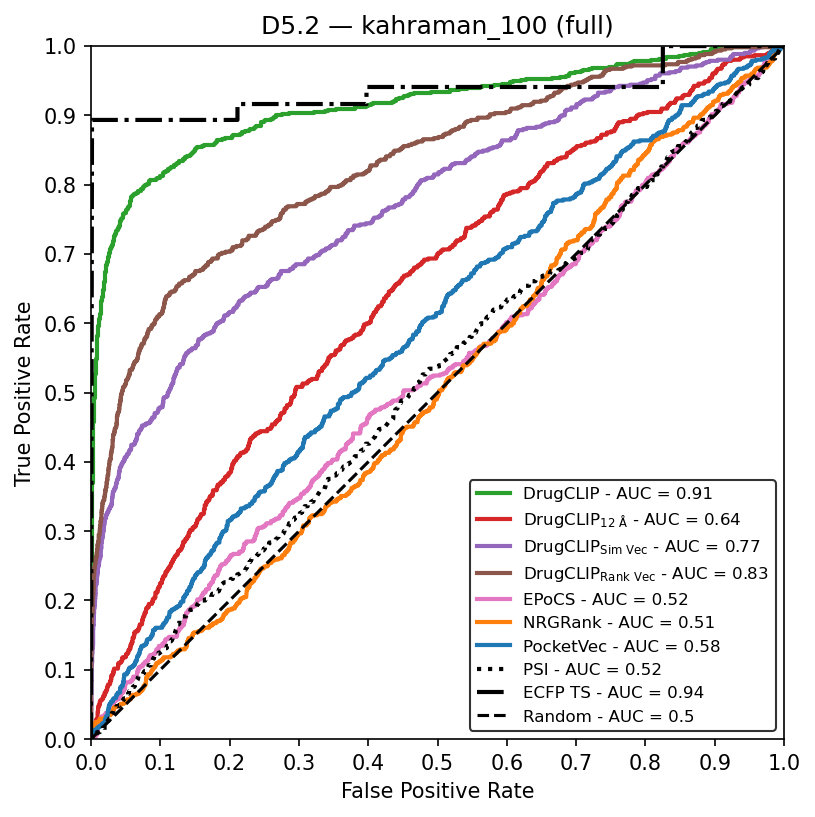

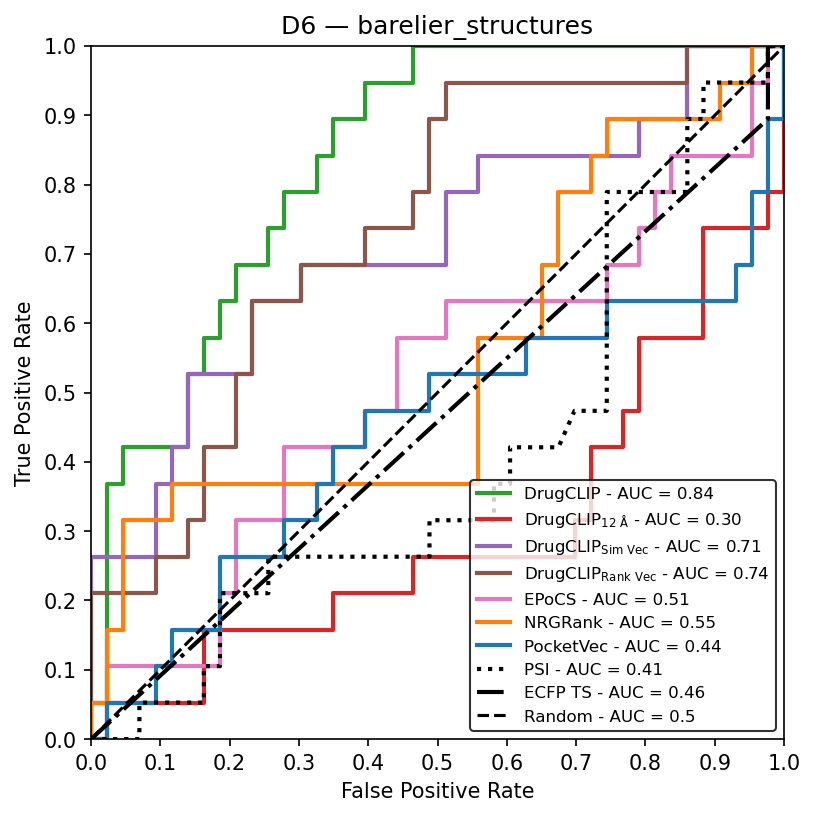

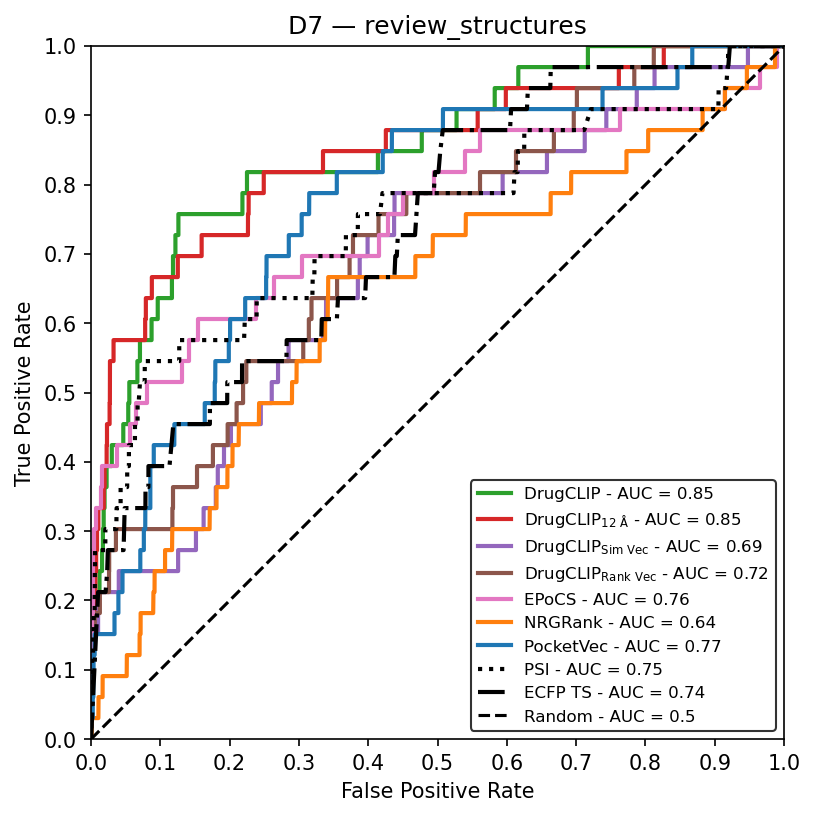

,drugclip,drugclip_12A512atoms,drugclip_cosvec,drugclip_rankvec,epocs,nrgrank,pocketvec,pocket_seqid,ligand_tanimoto
D1,0.951950,0.974782,0.838895,0.887012,1.000000,0.725800,0.965459,1.000000,0.784043
D1.2,0.998536,0.998581,0.968598,0.981651,1.000000,0.788706,0.997300,1.000000,0.999794
D2,0.997207,0.993088,0.980776,0.983146,1.000000,0.605706,0.957214,1.000000,1.000000
D3,0.648229,0.723536,0.651204,0.700352,0.812151,0.616726,0.662588,1.000000,0.821186
D4,0.638601,0.676579,0.599227,0.645944,0.838274,0.533561,0.712302,1.000000,0.821659
D5,0.921339,0.663384,0.774685,0.840104,0.554460,0.519110,0.601641,0.533010,0.966540
D5.2,0.913667,0.643460,0.770555,0.827889,0.521956,0.505708,0.584168,0.518148,0.936064
D6,0.837209,0.301102,0.713586,0.739290,0.514076,0.552020,0.441860,0.406977,0.460220
D7,0.851831,0.849058,0.687866,0.718801,0.756061,0.638249,0.773838,0.750881,0.737440


In [15]:
def labels_to_int(s: pd.Series) -> pd.Series:
    return s.astype(str).str.lower().str.strip().map({'active': 1, 'inactive': 0})


def deduplicate_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """Upper triangle of the comparison matrix, diagonal excluded: drop
    self-pairs (p1 == p2) and collapse (p1, p2) / (p2, p1) duplicates to one
    row. Every method here is a symmetric vector/pocket comparison, so both
    directions and the diagonal are redundant - keeping them just inflates N
    without adding information."""
    df = df[df['p1'] != df['p2']]
    pair_key = df.apply(lambda r: frozenset((r['p1'], r['p2'])), axis=1)
    return df.loc[~pair_key.duplicated()].reset_index(drop=True)


# Real pocket-matching methods, in reporting order (DrugCLIP variants, EPoCS,
# NRGRank, PocketVec), followed by the naive/baseline reference scores from
# 04_naive_baselines.ipynb.
REAL_METHODS = [
    ('drugclip',                 'drugclip_score'),
    ('drugclip_12A512atoms',     'drugclip_score_12A512atoms'),
    ('drugclip_cosvec',          'drugclip_cosvec_score'),
    ('drugclip_rankvec',         'drugclip_rankvec_score'),
    ('epocs',                    'epocs_score'),
    ('nrgrank',                  'nrgrank_score'),
    ('pocketvec',                'pocketvec_score'),
]

BASELINE_METHODS = [
    ('same_protein',    'same_protein_score'),
    ('same_ligand',     'same_ligand_score'),
    ('pocket_seqid',    'pocket_seqid_score'),
    ('ligand_tanimoto', 'ligand_tanimoto_score'),
]

# Full list, in report order - used for the tables/CSVs (sections 11 and 13).
METHODS = REAL_METHODS + BASELINE_METHODS

# same_protein / same_ligand are binary flags: a ROC/PR *curve* for a 0/1
# score is a single elbow, not informative next to continuous methods, and
# just clutters the legend. They're still fully reported in the tables/CSVs
# below - just not drawn. pocket_seqid / ligand_tanimoto are continuous and
# stay on the curves, styled as dashed reference lines (METHOD_LINESTYLES)
# so they read as baselines, not competing methods.
PLOT_METHODS = REAL_METHODS + [
    ('pocket_seqid',    'pocket_seqid_score'),
    ('ligand_tanimoto', 'ligand_tanimoto_score'),
]

METHOD_COLORS = {
    'drugclip':                'tab:green',
    'drugclip_12A512atoms':    'tab:red',
    'drugclip_cosvec':         'tab:purple',
    'drugclip_rankvec':        'tab:brown',
    'epocs':                   'tab:pink',
    'nrgrank':                 'tab:orange',
    'pocketvec':               'tab:blue',
    'same_protein':            'tab:gray',
    'same_ligand':              'tab:olive',
    'pocket_seqid':            'black',
    'ligand_tanimoto':         'black',
}

# default '-' (solid) for every real method; the two plotted baselines get a
# distinct dash pattern so they read as reference lines, not competing methods.
METHOD_LINESTYLES = {
    'pocket_seqid':    ':',
    'ligand_tanimoto': '-.',
}

METHOD_LABELS = {
    'drugclip':             'DrugCLIP',
    'drugclip_12A512atoms': r'DrugCLIP$_{12\ \mathrm{\AA}}$',
    'drugclip_cosvec':     r'DrugCLIP$_{\mathrm{Sim\ Vec}}$',
    'drugclip_rankvec':    r'DrugCLIP$_{\mathrm{Rank\ Vec}}$',
    'epocs':                'EPoCS',
    'nrgrank':              'NRGRank',
    'pocketvec':            'PocketVec',
    'same_protein':         'Sequence',
    'same_ligand':          'Ligand Code',
    'pocket_seqid':         'PSI',
    'ligand_tanimoto':      'ECFP TS',
}


def plot_roc(df: pd.DataFrame, dkey: str) -> dict:
    df = deduplicate_pairs(df)
    y = labels_to_int(df['lab'])
    fig, ax = plt.subplots(figsize=(6, 6), dpi = 150)
    ax.set_aspect('equal')
    aucs = {}
    for label, col in PLOT_METHODS:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        mask = y.notna() & s.notna()
        if mask.sum() == 0 or y[mask].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(y[mask], s[mask])
        auc = roc_auc_score(y[mask], s[mask])
        aucs[label] = auc
        ax.plot(fpr, tpr, color=METHOD_COLORS[label], lw=2, linestyle=METHOD_LINESTYLES.get(label, '-'),
                label=f'{METHOD_LABELS[label]} - AUC = {auc:.2f}')
    ax.plot([0, 1], [0, 1], '--', color='black', label='Random - AUC = 0.5')
    ticks = np.arange(0, 1.01, 0.1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
           xlim=(0, 1), ylim=(0, 1),
           title=f'{dkey} — {DATASETS[dkey]["pretty"]}')
    ax.legend(loc='lower right', fontsize=8, edgecolor='black')
    fig.savefig(FIGURES_DIR / f'prospeccts_{dkey}_roc.png', dpi=600, bbox_inches='tight')
    plt.show()
    return aucs


auc_table = {dkey: plot_roc(df, dkey) for dkey, df in out.items()}
pd.DataFrame(auc_table).T

## 10. Precision-Recall curves

PR curves are more informative than ROC on imbalanced datasets (D7 is 0.2% active; D5/D5.2 ~13%; D6 ~31%). The dashed black baseline is the positive prevalence — what a random classifier would achieve.

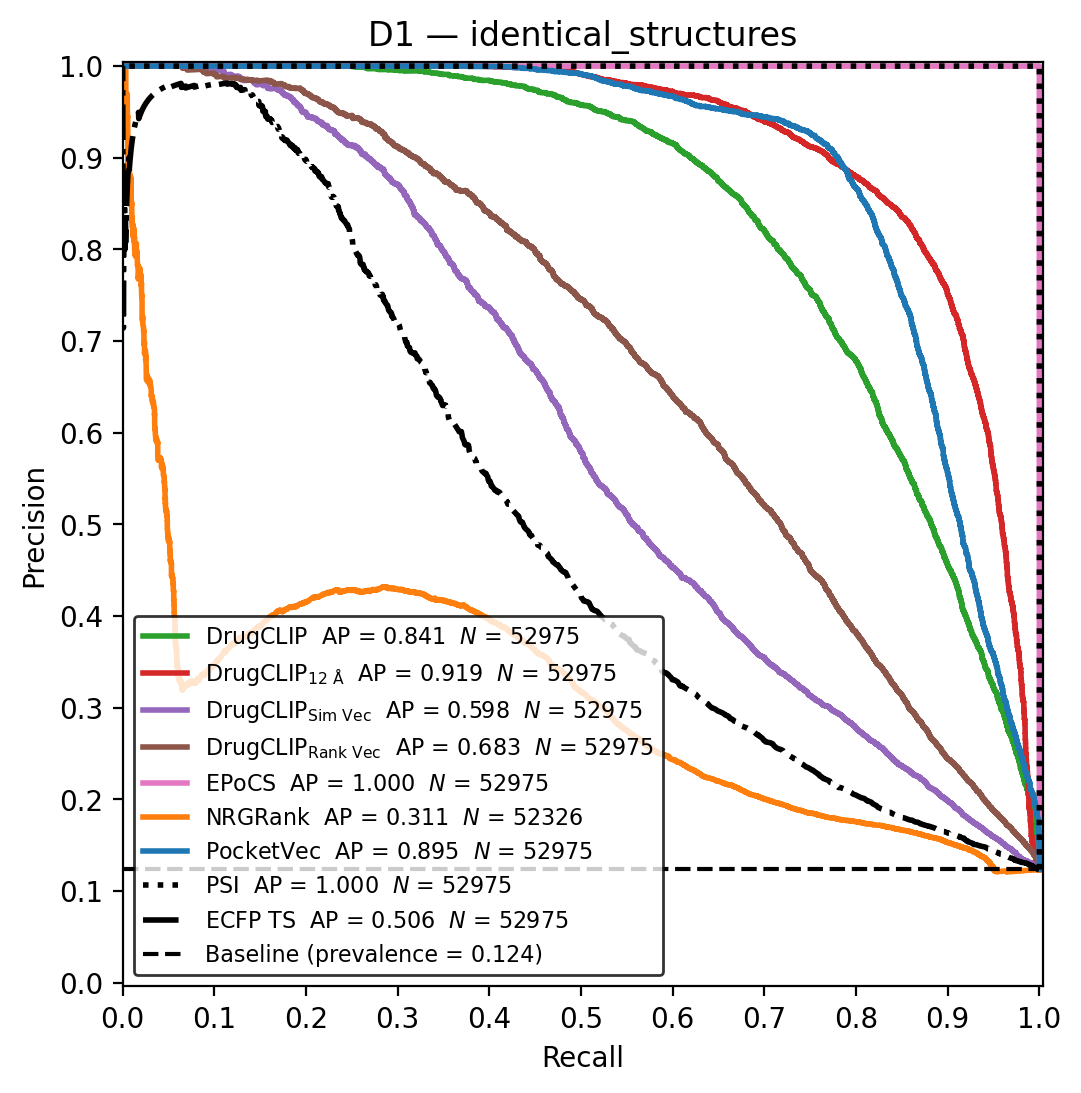

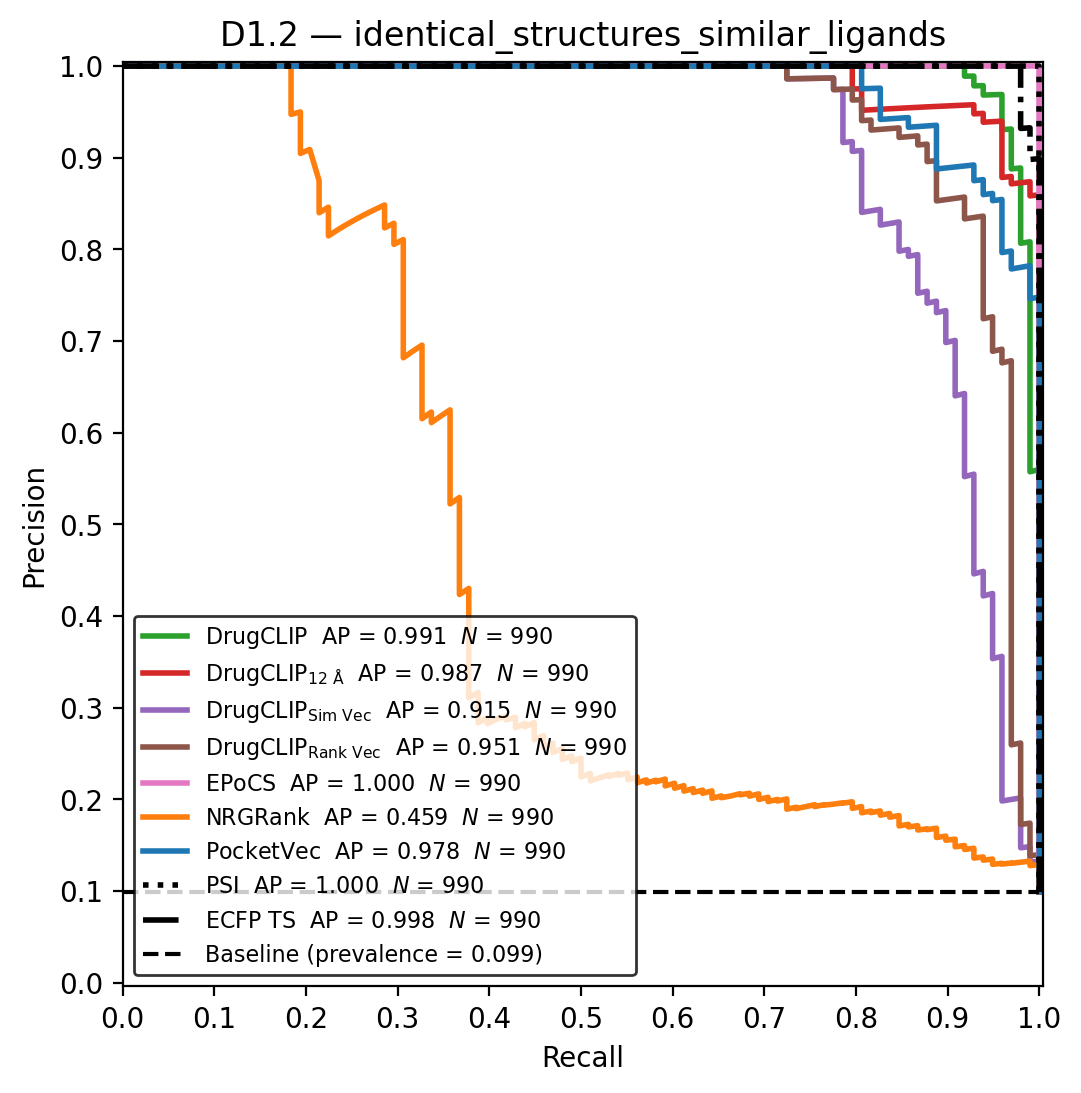

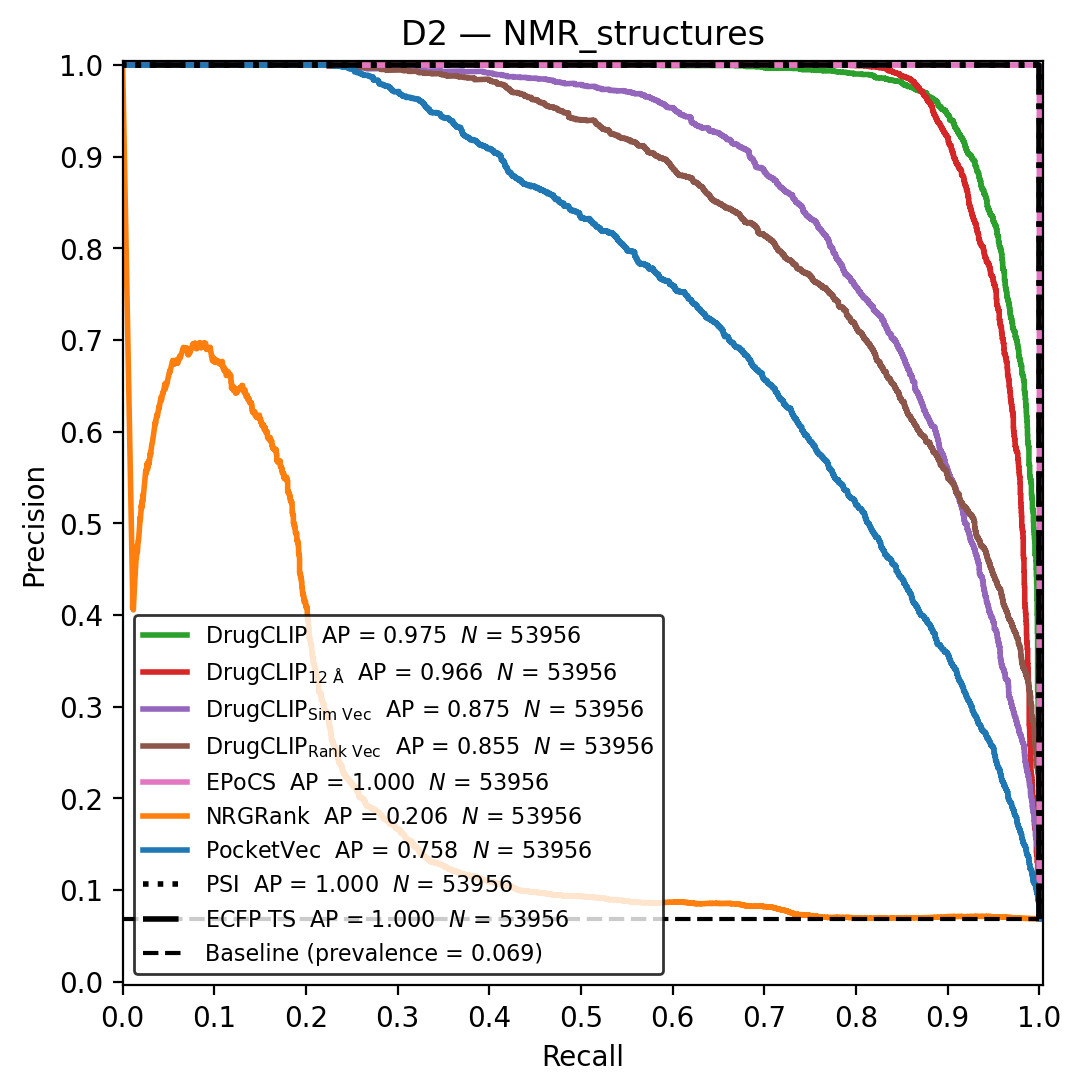

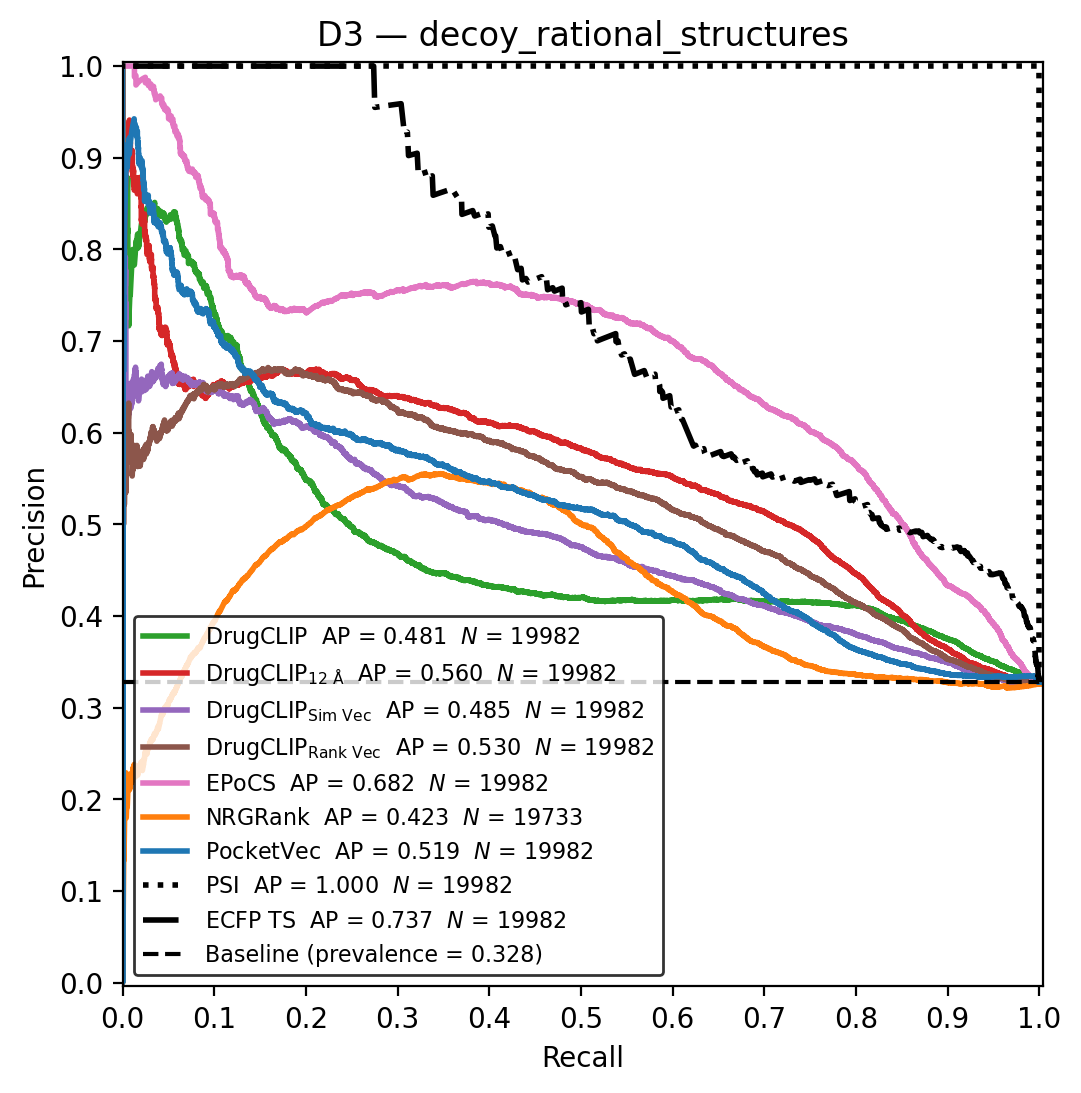

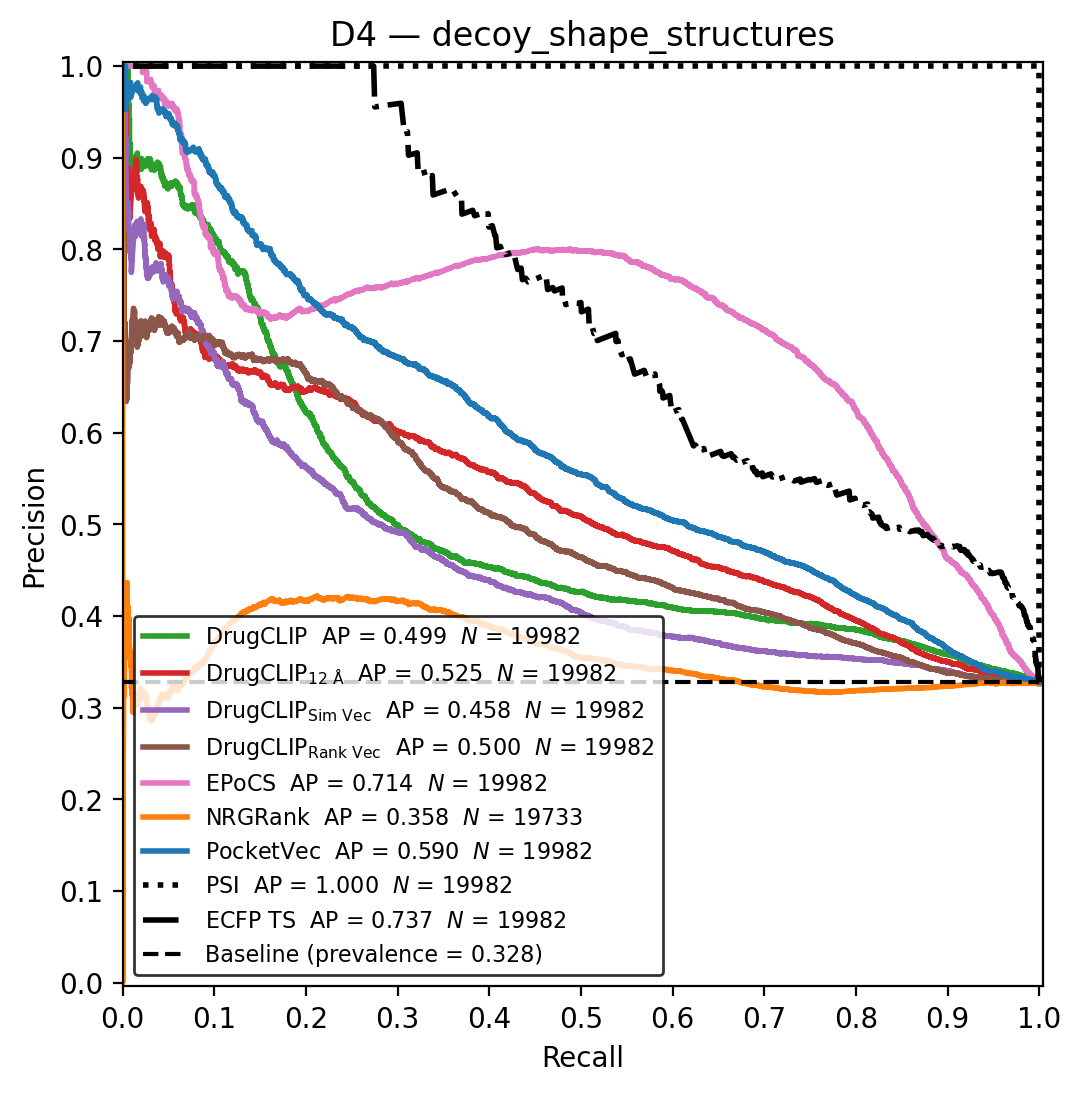

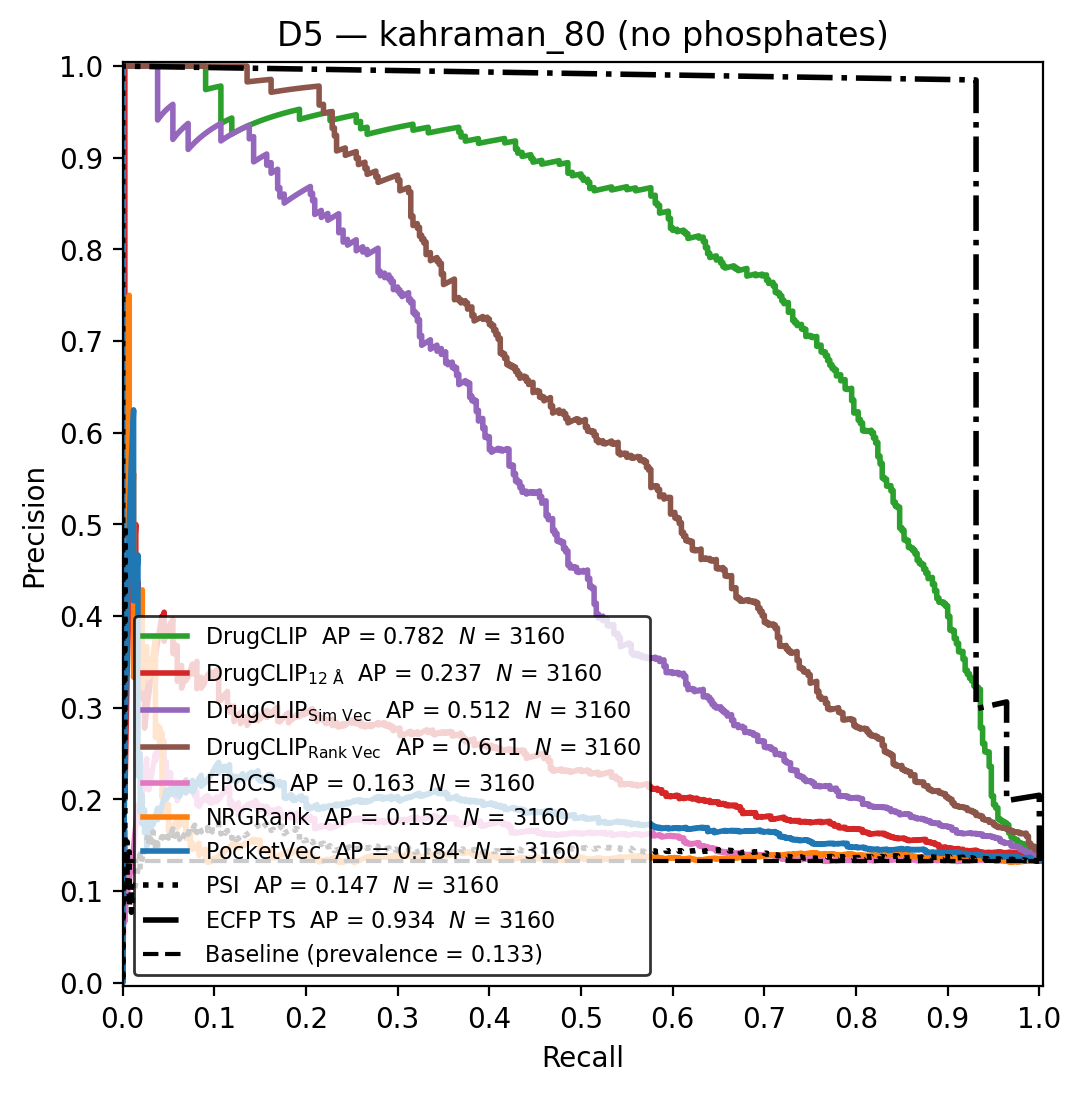

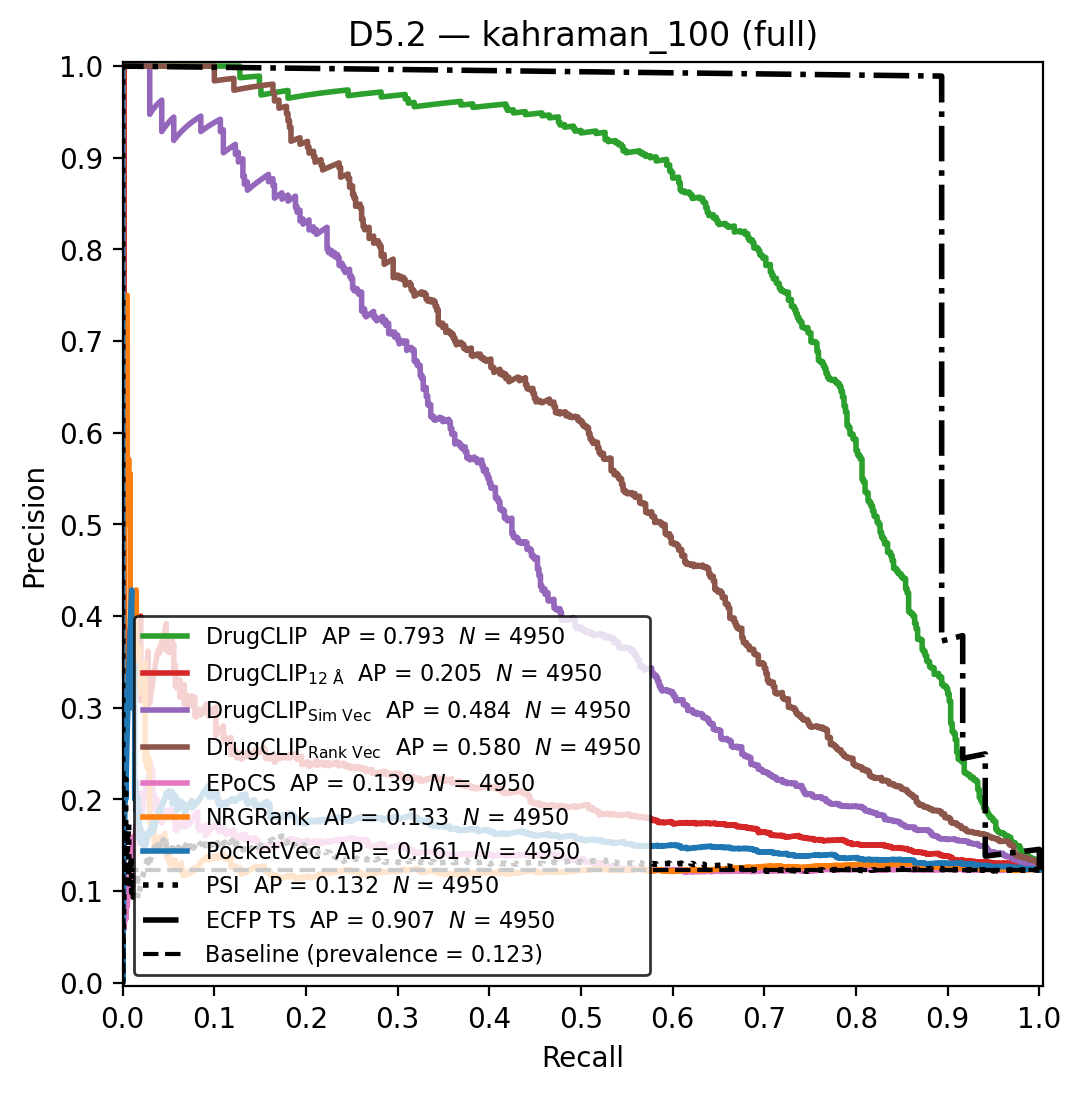

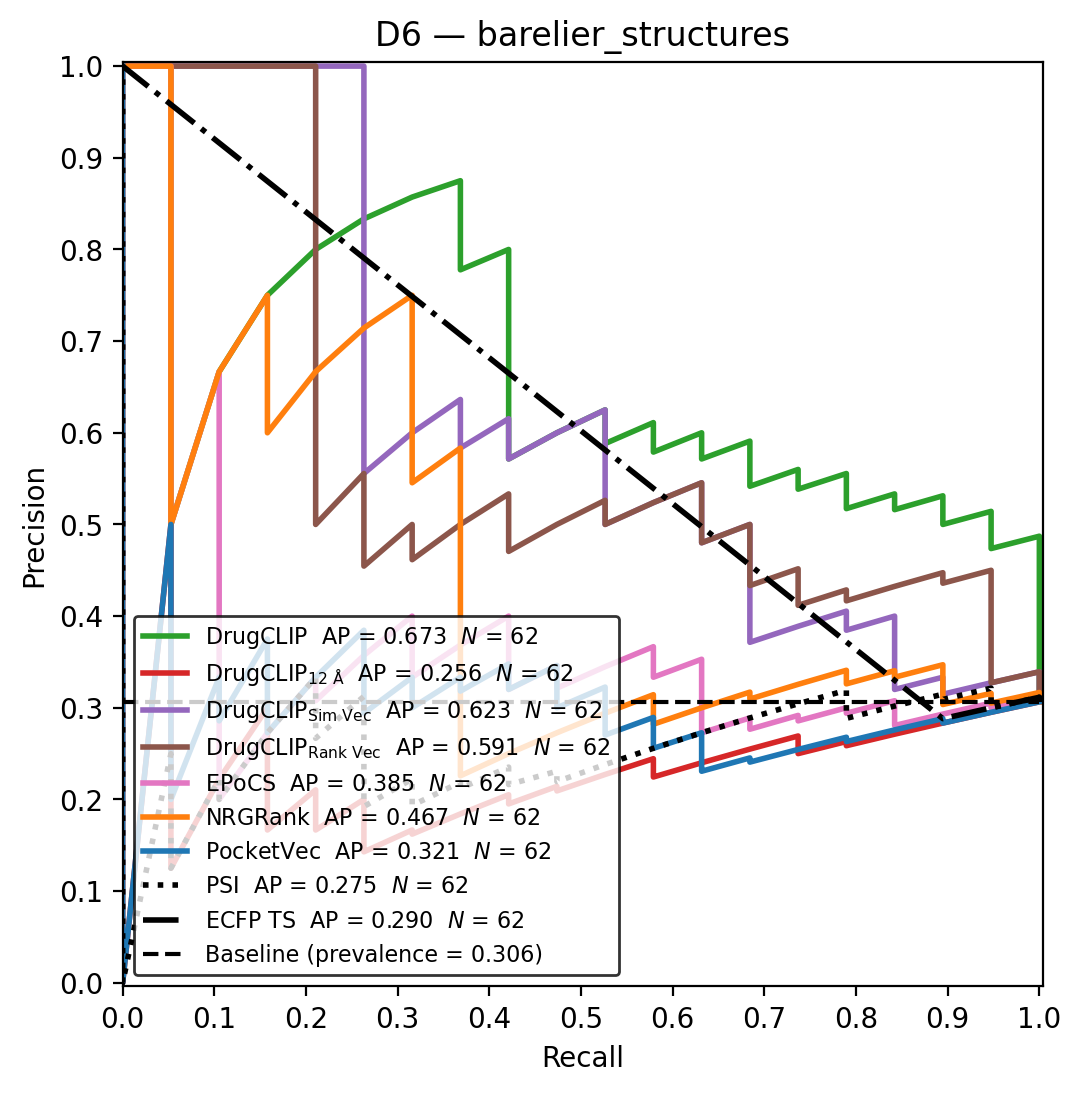

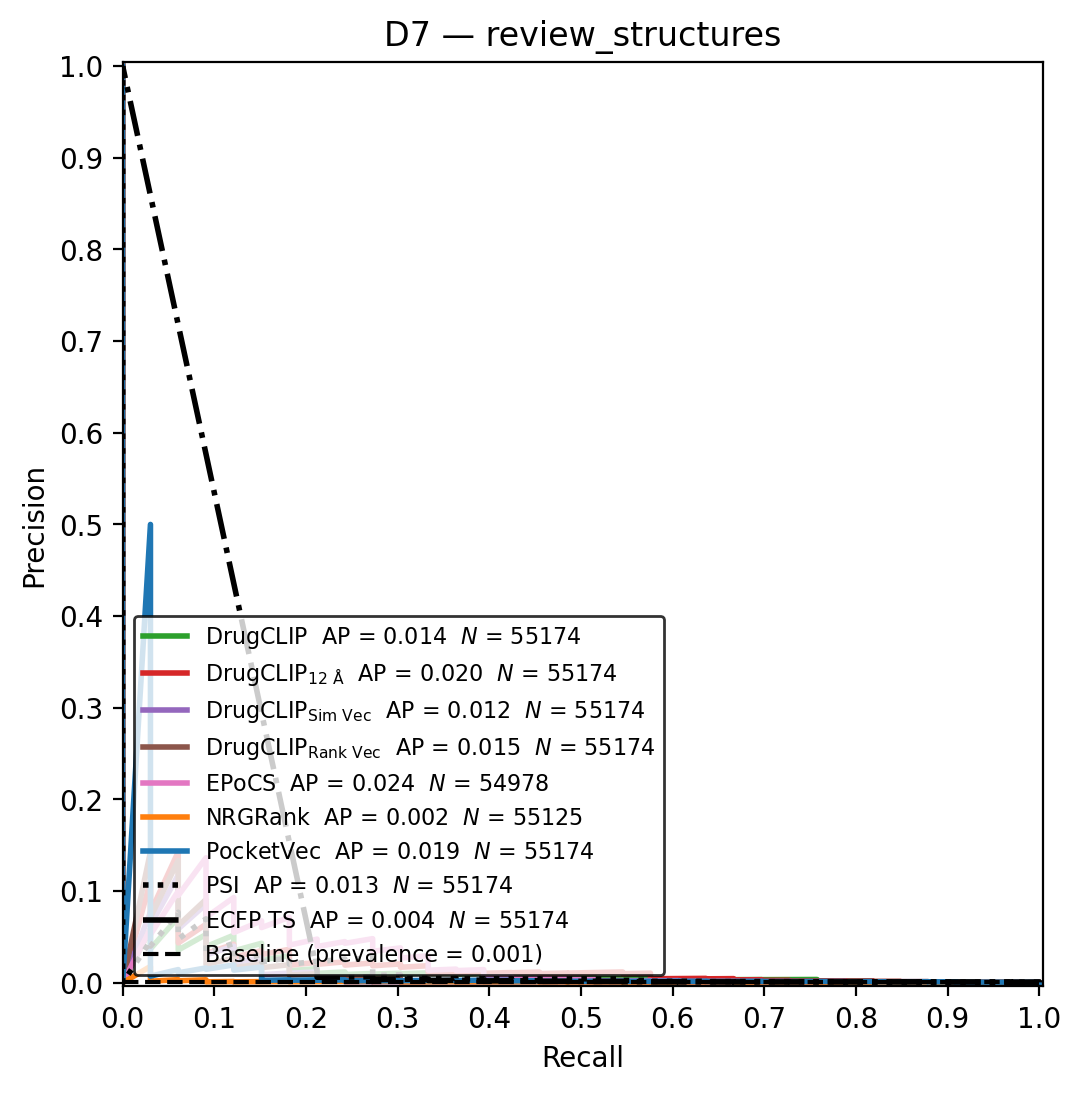

,drugclip,drugclip_12A512atoms,drugclip_cosvec,drugclip_rankvec,epocs,nrgrank,pocketvec,pocket_seqid,ligand_tanimoto
D1,0.841278,0.918827,0.597996,0.682919,1.000000,0.310748,0.894519,1.000000,0.506313
D1.2,0.990758,0.987265,0.915455,0.950532,1.000000,0.459149,0.978046,1.000000,0.998283
D2,0.975144,0.965701,0.875022,0.855382,1.000000,0.206102,0.758045,1.000000,1.000000
D3,0.480820,0.559614,0.484927,0.529594,0.682350,0.422753,0.518519,1.000000,0.736556
D4,0.498835,0.525089,0.458429,0.499534,0.713986,0.357591,0.590038,1.000000,0.736886
D5,0.782373,0.236862,0.512122,0.610662,0.163204,0.151995,0.184055,0.146776,0.934401
D5.2,0.793091,0.204747,0.483711,0.579592,0.138857,0.133366,0.161343,0.132458,0.907135
D6,0.673198,0.255690,0.623168,0.591249,0.384568,0.466604,0.321312,0.275076,0.289988
D7,0.013786,0.020010,0.012120,0.014772,0.024393,0.001709,0.018780,0.013110,0.004145


In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score


def plot_pr(df: pd.DataFrame, dkey: str) -> dict:
    df = deduplicate_pairs(df)
    y = labels_to_int(df['lab'])
    fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
    ax.set_aspect('equal')
    aps = {}
    for label, col in PLOT_METHODS:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        mask = y.notna() & s.notna()
        if mask.sum() == 0 or y[mask].nunique() < 2:
            continue
        prec, rec, _ = precision_recall_curve(y[mask], s[mask])
        ap = average_precision_score(y[mask], s[mask])
        aps[label] = ap
        ax.plot(rec, prec, color=METHOD_COLORS[label], lw=2, linestyle=METHOD_LINESTYLES.get(label, '-'),
                label=f'{METHOD_LABELS[label]}  AP = {ap:.3f}  $N$ = {int(mask.sum())}')
    pos_rate = y.dropna().mean()
    ax.hlines(pos_rate, 0, 1, linestyles='--', colors='black',
              label=f'Baseline (prevalence = {pos_rate:.3f})')
    ticks = np.arange(0, 1.01, 0.1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set(xlabel='Recall', ylabel='Precision',
           xlim=(0, 1.004), ylim=(-0.004, 1.004),
           title=f'{dkey} — {DATASETS[dkey]["pretty"]}')
    ax.legend(loc='lower left', fontsize=8, edgecolor='black')
    fig.savefig(FIGURES_DIR / f'prospeccts_{dkey}_pr.png', dpi=600, bbox_inches='tight')
    plt.show()
    return aps


ap_table = {dkey: plot_pr(df, dkey) for dkey, df in out.items()}
pd.DataFrame(ap_table).T

## 11. Optimal score thresholds and binary classification metrics

For each (dataset, method), find the score threshold that maximizes a chosen criterion and compute the full battery of binary-classification metrics at that operating point.

**Why pick a threshold at all?** ROC-AUC and AP measure ranking quality and are threshold-free. To report precision/recall/F1/MCC you have to commit to a threshold — equivalent to choosing where you'd draw the active/inactive line in practice.

**Optimization criterion choices** (default: Youden's J):

| criterion | maximizes | best for |
|---|---|---|
| `youden`  | TPR − FPR (Youden's J) | balanced classes; classical ROC operating point |
| `f1`      | F1 = 2·P·R / (P+R) | imbalanced classes when you care about the positive class |
| `mcc`     | Matthews correlation coefficient | imbalanced classes; single robust score |
| `balanced_accuracy` | (TPR + TNR) / 2 | imbalanced classes; sensitivity/specificity tradeoff |

PROSPECCTS datasets are imbalanced, so the four criteria can disagree. We compute all of them and report metrics at the **Youden's J** operating point as the headline; a side table shows how the threshold itself differs across criteria.

**Implementation note.** The threshold sweep is vectorized via cumulative TP/FP — it visits every distinct cut point in O(n log n) time per (dataset, method), so D2/D7's 100k-pair sweeps are still fast.

In [17]:
EPS = 1e-12
CRITERIA = ['youden', 'f1', 'mcc', 'balanced_accuracy']


def threshold_sweep(y: np.ndarray, scores: np.ndarray) -> dict:
    """Vectorized sweep of every distinct cut point.

    For a sorted-descending score list, the kth cut point predicts the top k+1
    items as positive. Cumulative TP/FP give all confusion-matrix counts in
    one shot, then every metric is computed elementwise.
    """
    s = np.asarray(scores, dtype=float)
    y = np.asarray(y, dtype=int)
    order = np.argsort(-s, kind='stable')
    y_sorted = y[order]
    s_sorted = s[order]

    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    P = int(y.sum())
    N = int(len(y) - P)
    fn = P - tp
    tn = N - fp

    precision = tp / np.maximum(tp + fp, EPS)
    recall    = tp / max(P, 1)
    specificity = tn / max(N, 1)
    accuracy = (tp + tn) / (P + N)
    balanced_accuracy = 0.5 * (recall + specificity)
    f1 = 2 * precision * recall / np.maximum(precision + recall, EPS)
    youden = recall - fp / max(N, 1)
    mcc_denom = np.sqrt(np.maximum(
        (tp + fp).astype(float) * (tp + fn) * (tn + fp) * (tn + fn), EPS))
    mcc = (tp.astype(float) * tn - fp.astype(float) * fn) / mcc_denom

    return {
        'thresholds': s_sorted,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision, 'recall': recall, 'specificity': specificity,
        'accuracy': accuracy, 'balanced_accuracy': balanced_accuracy,
        'f1': f1, 'mcc': mcc, 'youden': youden,
    }


def best_threshold(sweep: dict, criterion: str) -> int:
    crit_array = sweep['youden' if criterion == 'youden' else criterion]
    return int(np.argmax(crit_array))


def metrics_at_threshold(sweep: dict, idx: int, P: int, N: int) -> dict:
    return {
        'threshold':         float(sweep['thresholds'][idx]),
        'tp':                int(sweep['tp'][idx]),
        'fp':                int(sweep['fp'][idx]),
        'fn':                int(sweep['fn'][idx]),
        'tn':                int(sweep['tn'][idx]),
        'precision':         float(sweep['precision'][idx]),
        'recall':            float(sweep['recall'][idx]),
        'specificity':       float(sweep['specificity'][idx]),
        'accuracy':          float(sweep['accuracy'][idx]),
        'balanced_accuracy': float(sweep['balanced_accuracy'][idx]),
        'f1':                float(sweep['f1'][idx]),
        'mcc':               float(sweep['mcc'][idx]),
        'youden_j':          float(sweep['youden'][idx]),
        'n':                 P + N, 'n_pos': P, 'n_neg': N,
    }


def evaluate_method(df: pd.DataFrame, score_col: str, criterion: str = 'youden'):
    """Return (metrics dict, threshold-by-criterion dict, ROC-AUC, PR-AUC)."""
    df = deduplicate_pairs(df)
    y = labels_to_int(df['lab'])
    s = pd.to_numeric(df[score_col], errors='coerce')
    mask = y.notna() & s.notna()
    if mask.sum() == 0 or y[mask].nunique() < 2:
        return None, None, np.nan, np.nan
    y_arr = y[mask].astype(int).to_numpy()
    s_arr = s[mask].to_numpy()
    P, N = int(y_arr.sum()), int((1 - y_arr).sum())

    sweep = threshold_sweep(y_arr, s_arr)
    headline_idx = best_threshold(sweep, criterion)
    metrics = metrics_at_threshold(sweep, headline_idx, P, N)
    metrics['auc']  = roc_auc_score(y_arr, s_arr)
    metrics['ap']   = average_precision_score(y_arr, s_arr)
    metrics['criterion'] = criterion

    thr_by_criterion = {
        c: float(sweep['thresholds'][best_threshold(sweep, c)]) for c in CRITERIA
    }
    return metrics, thr_by_criterion, metrics['auc'], metrics['ap']


PRIMARY_CRITERION = 'youden'

records = []
threshold_records = []
for dkey, df in out.items():
    for method, score_col in METHODS:
        if score_col not in df.columns:
            continue
        metrics, thr_by_crit, _, _ = evaluate_method(df, score_col, PRIMARY_CRITERION)
        if metrics is None:
            continue
        metrics.update({'dataset': dkey, 'method': method})
        records.append(metrics)
        threshold_records.append({
            'dataset': dkey, 'method': method,
            **{f'thr_{c}': thr_by_crit[c] for c in CRITERIA},
        })

metrics_df = (pd.DataFrame(records)
              .set_index(['dataset', 'method'])
              [['threshold', 'tp', 'fp', 'fn', 'tn',
                'precision', 'recall', 'specificity',
                'accuracy', 'balanced_accuracy', 'f1', 'mcc', 'youden_j',
                'auc', 'ap', 'n', 'n_pos', 'n_neg']])
metrics_df

threshold    tp     fp    fn     tn  precision  \
dataset method                                                                 
D1      drugclip               0.341240  5587   4237   965  42186   0.568709   
        drugclip_12A512atoms   0.869183  6006   2504   546  43919   0.705758   
        drugclip_cosvec        0.426023  4735   9346  1817  37077   0.336269   
        drugclip_rankvec       0.846089  5016   6517  1536  39906   0.434926   
        epocs                 -2.814306  6552      0     0  46423   1.000000   
...                                 ...   ...    ...   ...    ...        ...   
D7      pocketvec              0.780843    26  17352     7  37789   0.001496   
        same_protein           0.000000    33      4     0  55137   0.891892   
        same_ligand            0.000000    33    559     0  54582   0.055743   
        pocket_seqid           0.431677    18   4268    15  50873   0.004200   
        ligand_tanimoto        0.101124    29  27787     4  27354   0.001043   

                                recall  specificity  accuracy  \
dataset method                                                  
D1      drugclip              0.852717     0.908731  0.901803   
        drugclip_12A512atoms  0.916667     0.946061  0.942426   
        drugclip_cosvec       0.722680     0.798677  0.789278   
        drugclip_rankvec      0.765568     0.859617  0.847985   
        epocs                 1.000000     1.000000  1.000000   
...                                ...          ...       ...   
D7      pocketvec             0.787879     0.685316  0.685377   
        same_protein          1.000000     0.999927  0.999928   
        same_ligand           1.000000     0.989862  0.989868   
        pocket_seqid          0.545455     0.922598  0.922373   
        ligand_tanimoto       0.878788     0.496074  0.496303   

                              balanced_accuracy        f1       mcc  youden_j  \
dataset method                                                                  
D1      drugclip                       0.880724  0.682340  0.644991  0.761447   
        drugclip_12A512atoms           0.931364  0.797504  0.773488  0.862728   
        drugclip_cosvec                0.760679  0.458973  0.388536  0.521357   
        drugclip_rankvec               0.812592  0.554714  0.498736  0.625185   
        epocs                          1.000000  1.000000  1.000000  1.000000   
...                                         ...       ...       ...       ...   
D7      pocketvec                      0.736597  0.002987  0.024906  0.473195   
        same_protein                   0.999964  0.942857  0.944366  0.999927   
        same_ligand                    0.994931  0.105600  0.234900  0.989862   
        pocket_seqid                   0.734026  0.008335  0.042752  0.468053   
        ligand_tanimoto                0.687431  0.002083  0.018331  0.374862   

                                   auc        ap      n  n_pos  n_neg  
dataset method                                                         
D1      drugclip              0.951950  0.841278  52975   6552  46423  
        drugclip_12A512atoms  0.974782  0.918827  52975   6552  46423  
        drugclip_cosvec       0.838895  0.597996  52975   6552  46423  
        drugclip_rankvec      0.887012  0.682919  52975   6552  46423  
        epocs                 1.000000  1.000000  52975   6552  46423  
...                                ...       ...    ...    ...    ...  
D7      pocketvec             0.773838  0.018780  55174     33  55141  
        same_protein          0.499964  0.000598  55174     33  55141  
        same_ligand           0.600992  0.003095  55174     33  55141  
        pocket_seqid          0.750881  0.013110  55174     33  55141  
        ligand_tanimoto       0.737440  0.004145  55174     33  55141  

[99 rows x 18 columns]

In [18]:
# How does the optimal threshold itself change across criteria?
threshold_df = (pd.DataFrame(threshold_records)
                .set_index(['dataset', 'method']))
threshold_df

thr_youden    thr_f1   thr_mcc  \
dataset method                                                 
D1      drugclip                0.341240  0.483613  0.530640   
        drugclip_12A512atoms    0.869183  0.895135  0.895135   
        drugclip_cosvec         0.426023  0.664351  0.703154   
        drugclip_rankvec        0.846089  0.883507  0.902811   
        epocs                  -2.814306 -2.814306 -2.814306   
...                                  ...       ...       ...   
D7      pocketvec               0.780843  0.927587  0.927587   
        same_protein            0.000000  0.000000  0.000000   
        same_ligand             0.000000  1.000000  1.000000   
        pocket_seqid            0.431677  0.764895  0.636296   
        ligand_tanimoto         0.101124  1.000000  1.000000   

                              thr_balanced_accuracy  
dataset method                                       
D1      drugclip                           0.341240  
        drugclip_12A512atoms               0.869183  
        drugclip_cosvec                    0.426023  
        drugclip_rankvec                   0.846089  
        epocs                             -2.814306  
...                                             ...  
D7      pocketvec                          0.780843  
        same_protein                       0.000000  
        same_ligand                        0.000000  
        pocket_seqid                       0.431677  
        ligand_tanimoto                    0.101124  

[99 rows x 4 columns]

In [19]:
metrics_df.to_csv(RESULTS_DIR / f'prospeccts_metrics_at_{PRIMARY_CRITERION}.csv')
threshold_df.to_csv(RESULTS_DIR / 'prospeccts_thresholds_by_criterion.csv')
print(f'Saved -> {RESULTS_DIR / f"prospeccts_metrics_at_{PRIMARY_CRITERION}.csv"}')
print(f'Saved -> {RESULTS_DIR / "prospeccts_thresholds_by_criterion.csv"}')

Saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_metrics_at_youden.csv
Saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_thresholds_by_criterion.csv


## 12. Distance distributions: active vs inactive pairs

For each dataset, one figure with subplots per method. Each subplot overlays the **distance** distribution (not the score) for active pairs (red) and inactive pairs (blue). Histograms are normalized (`density=True`) so the visual comparison isn't dominated by class imbalance.

A method that perfectly separates the classes will show two non-overlapping clouds. Heavy overlap → method has no discriminative signal at any threshold. The PR/ROC curves you saw above are just summaries of the area under these overlap regions — the histograms show *why* a method scores what it does.

**Why EPoCS hits 1.000 AUC on D1 / D1.2 / D2.** Active pairs in those datasets are between *the same protein chain* (identical structures, similar-ligand variants of identical structures, NMR conformers of the same chain). EPoCS uses a mean-pooled ESM-2 protein language model embedding — for the same chain, that embedding is essentially deterministic, so the Euclidean distance for active pairs is ≈ 0. Inactive pairs are between different chains and have non-trivial distances. The two distributions don't overlap at all → trivially perfect ranking. This is more a property of how those benchmarks define "active" than a sign that EPoCS understands pockets.

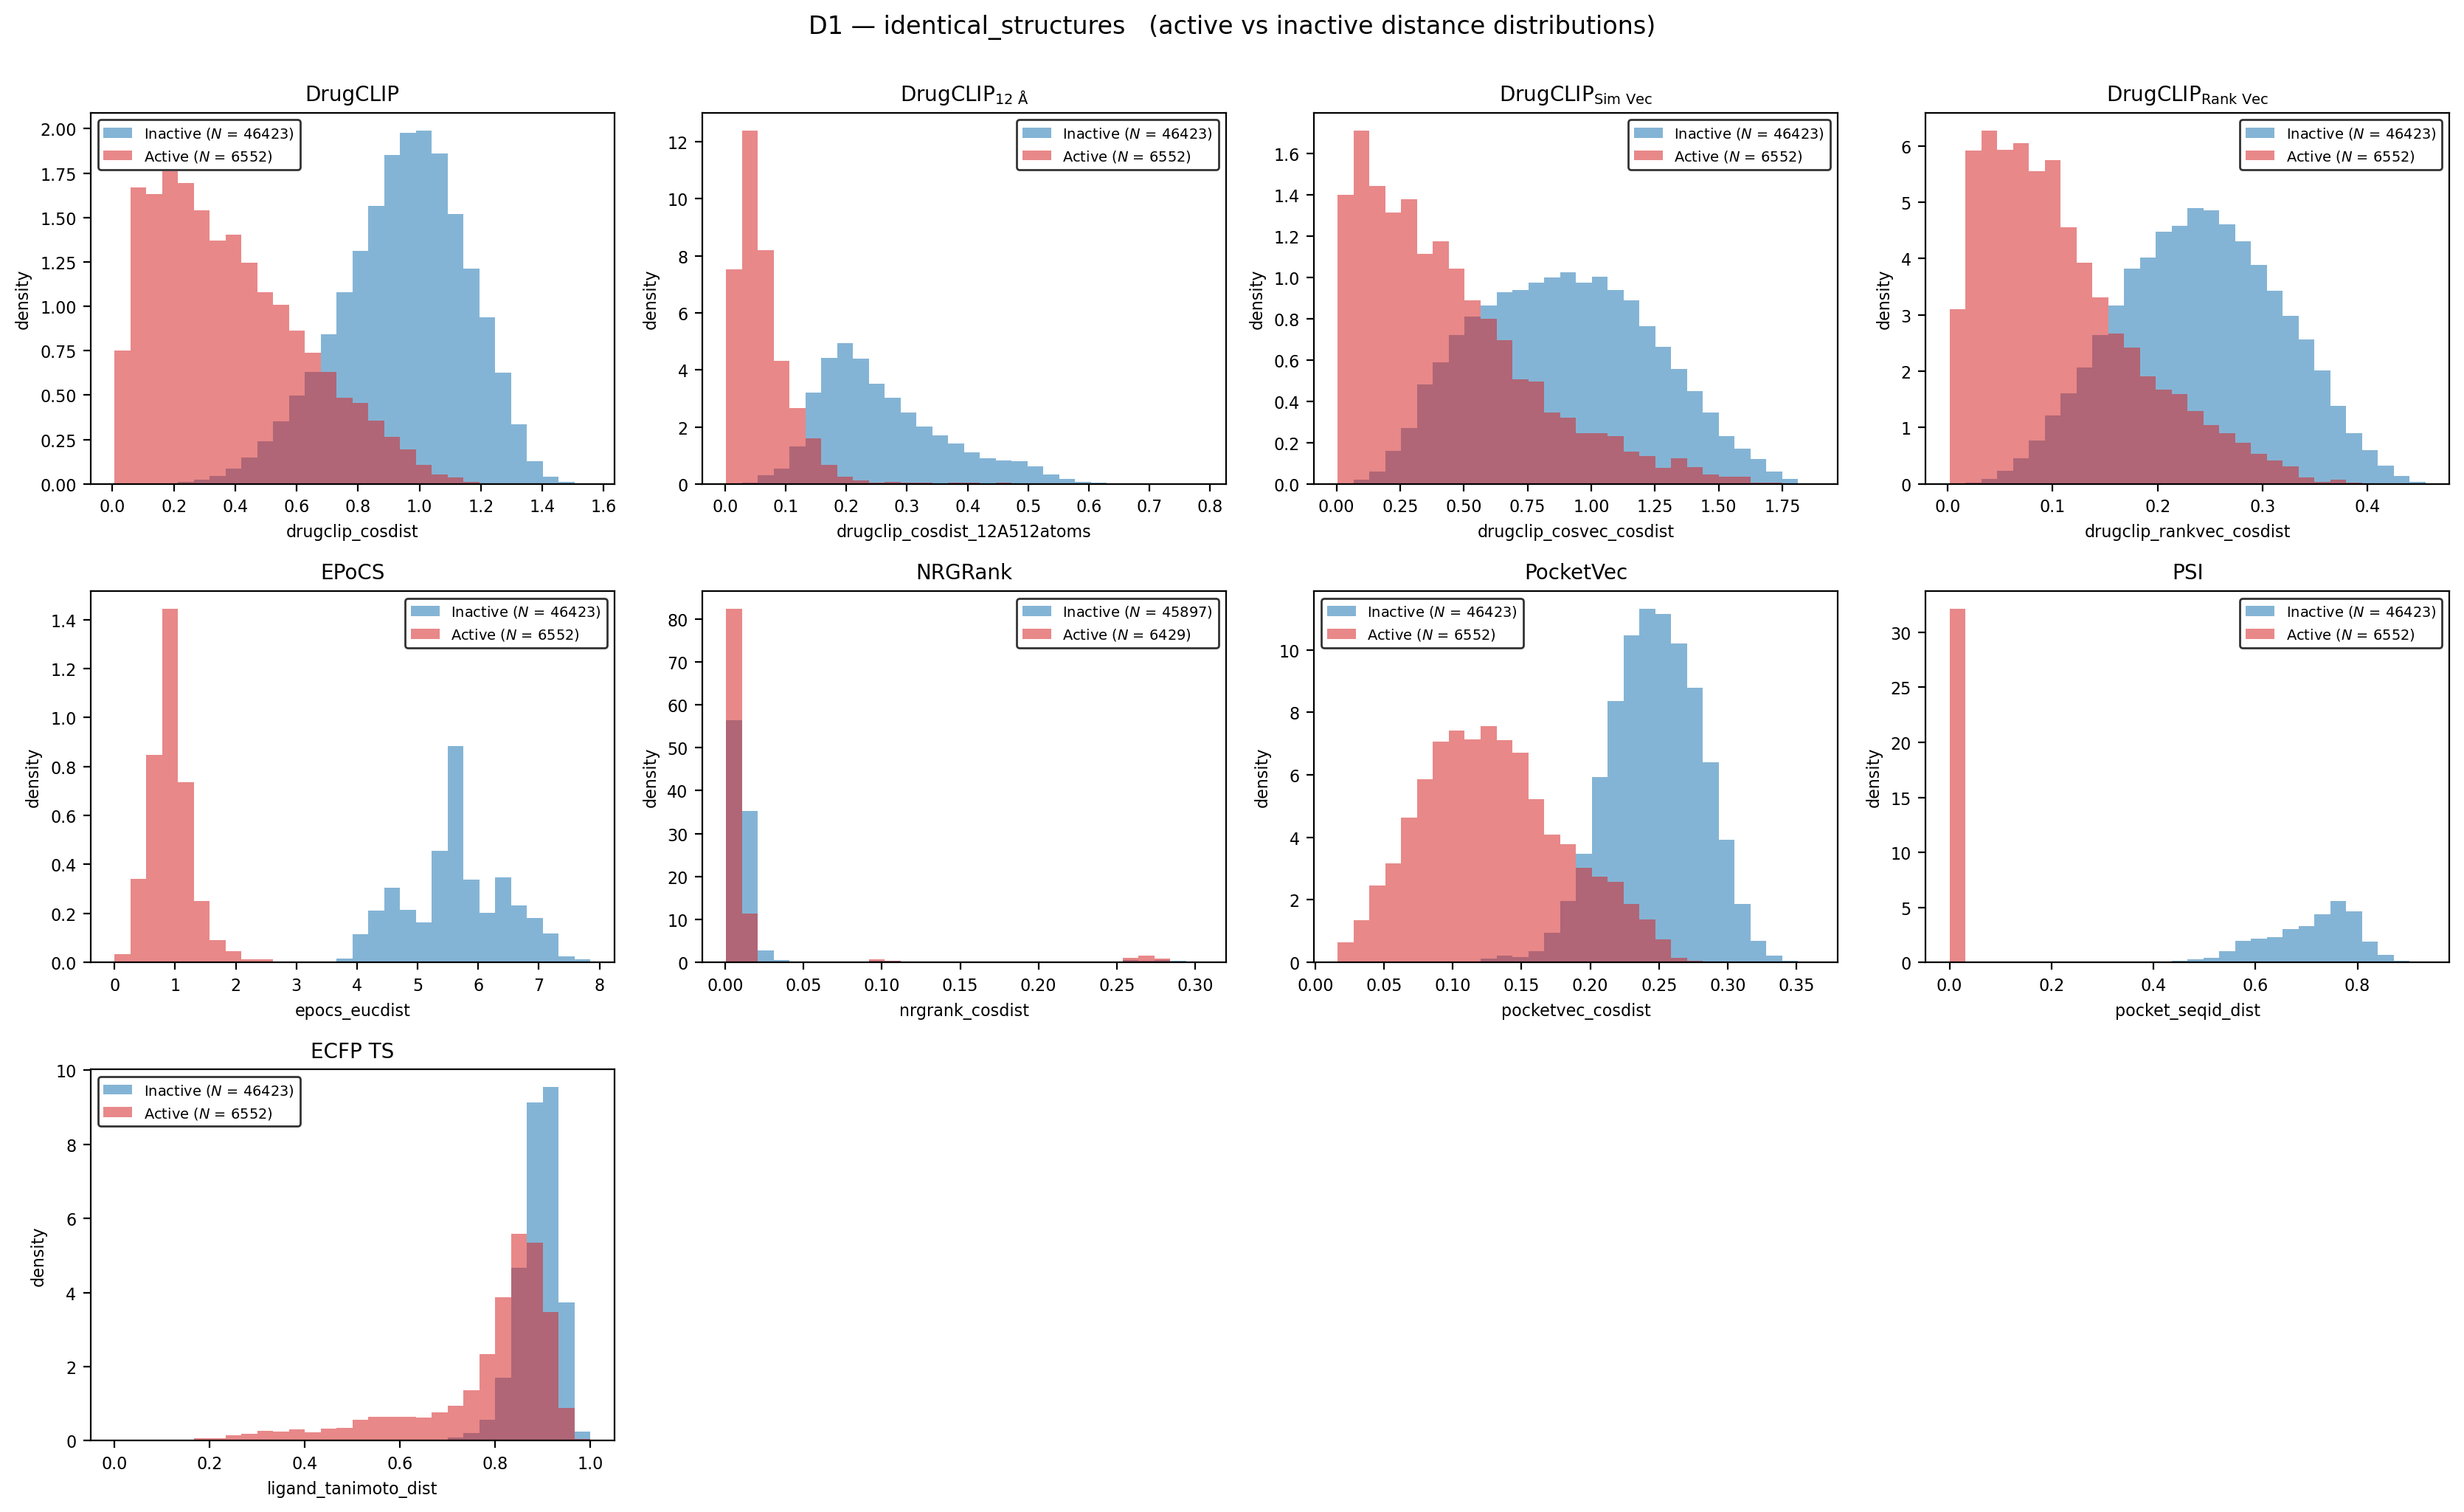

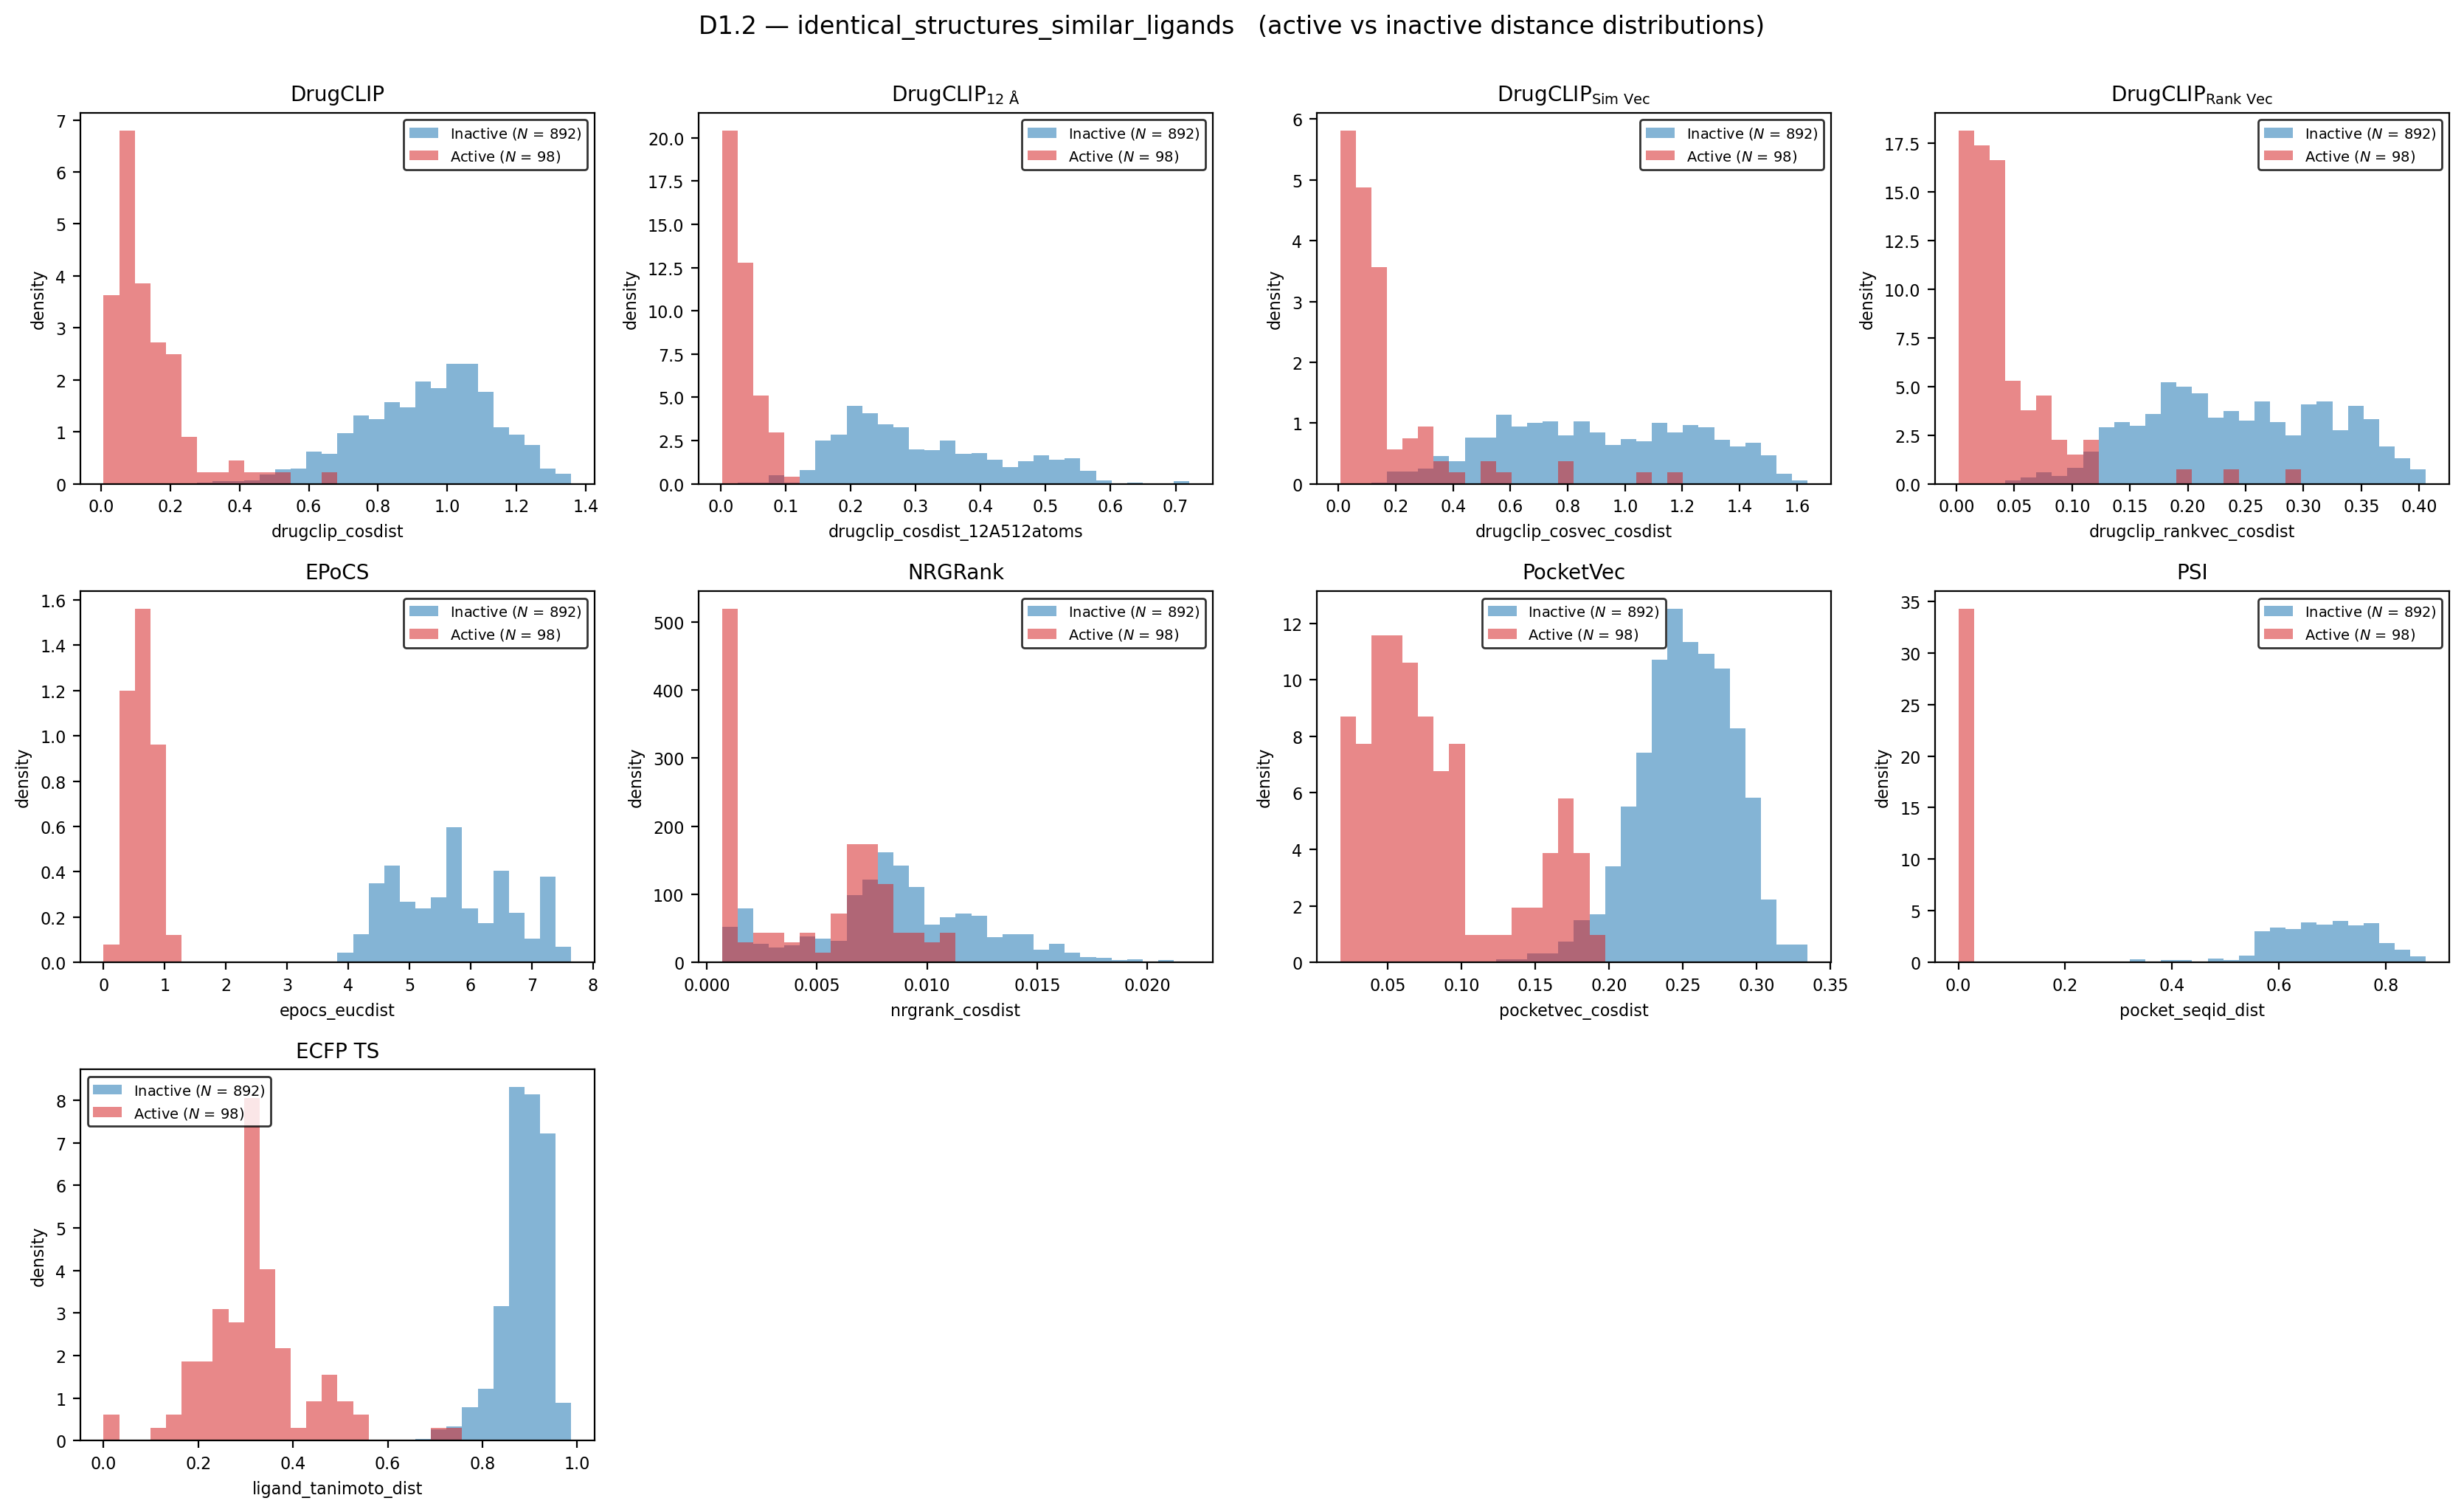

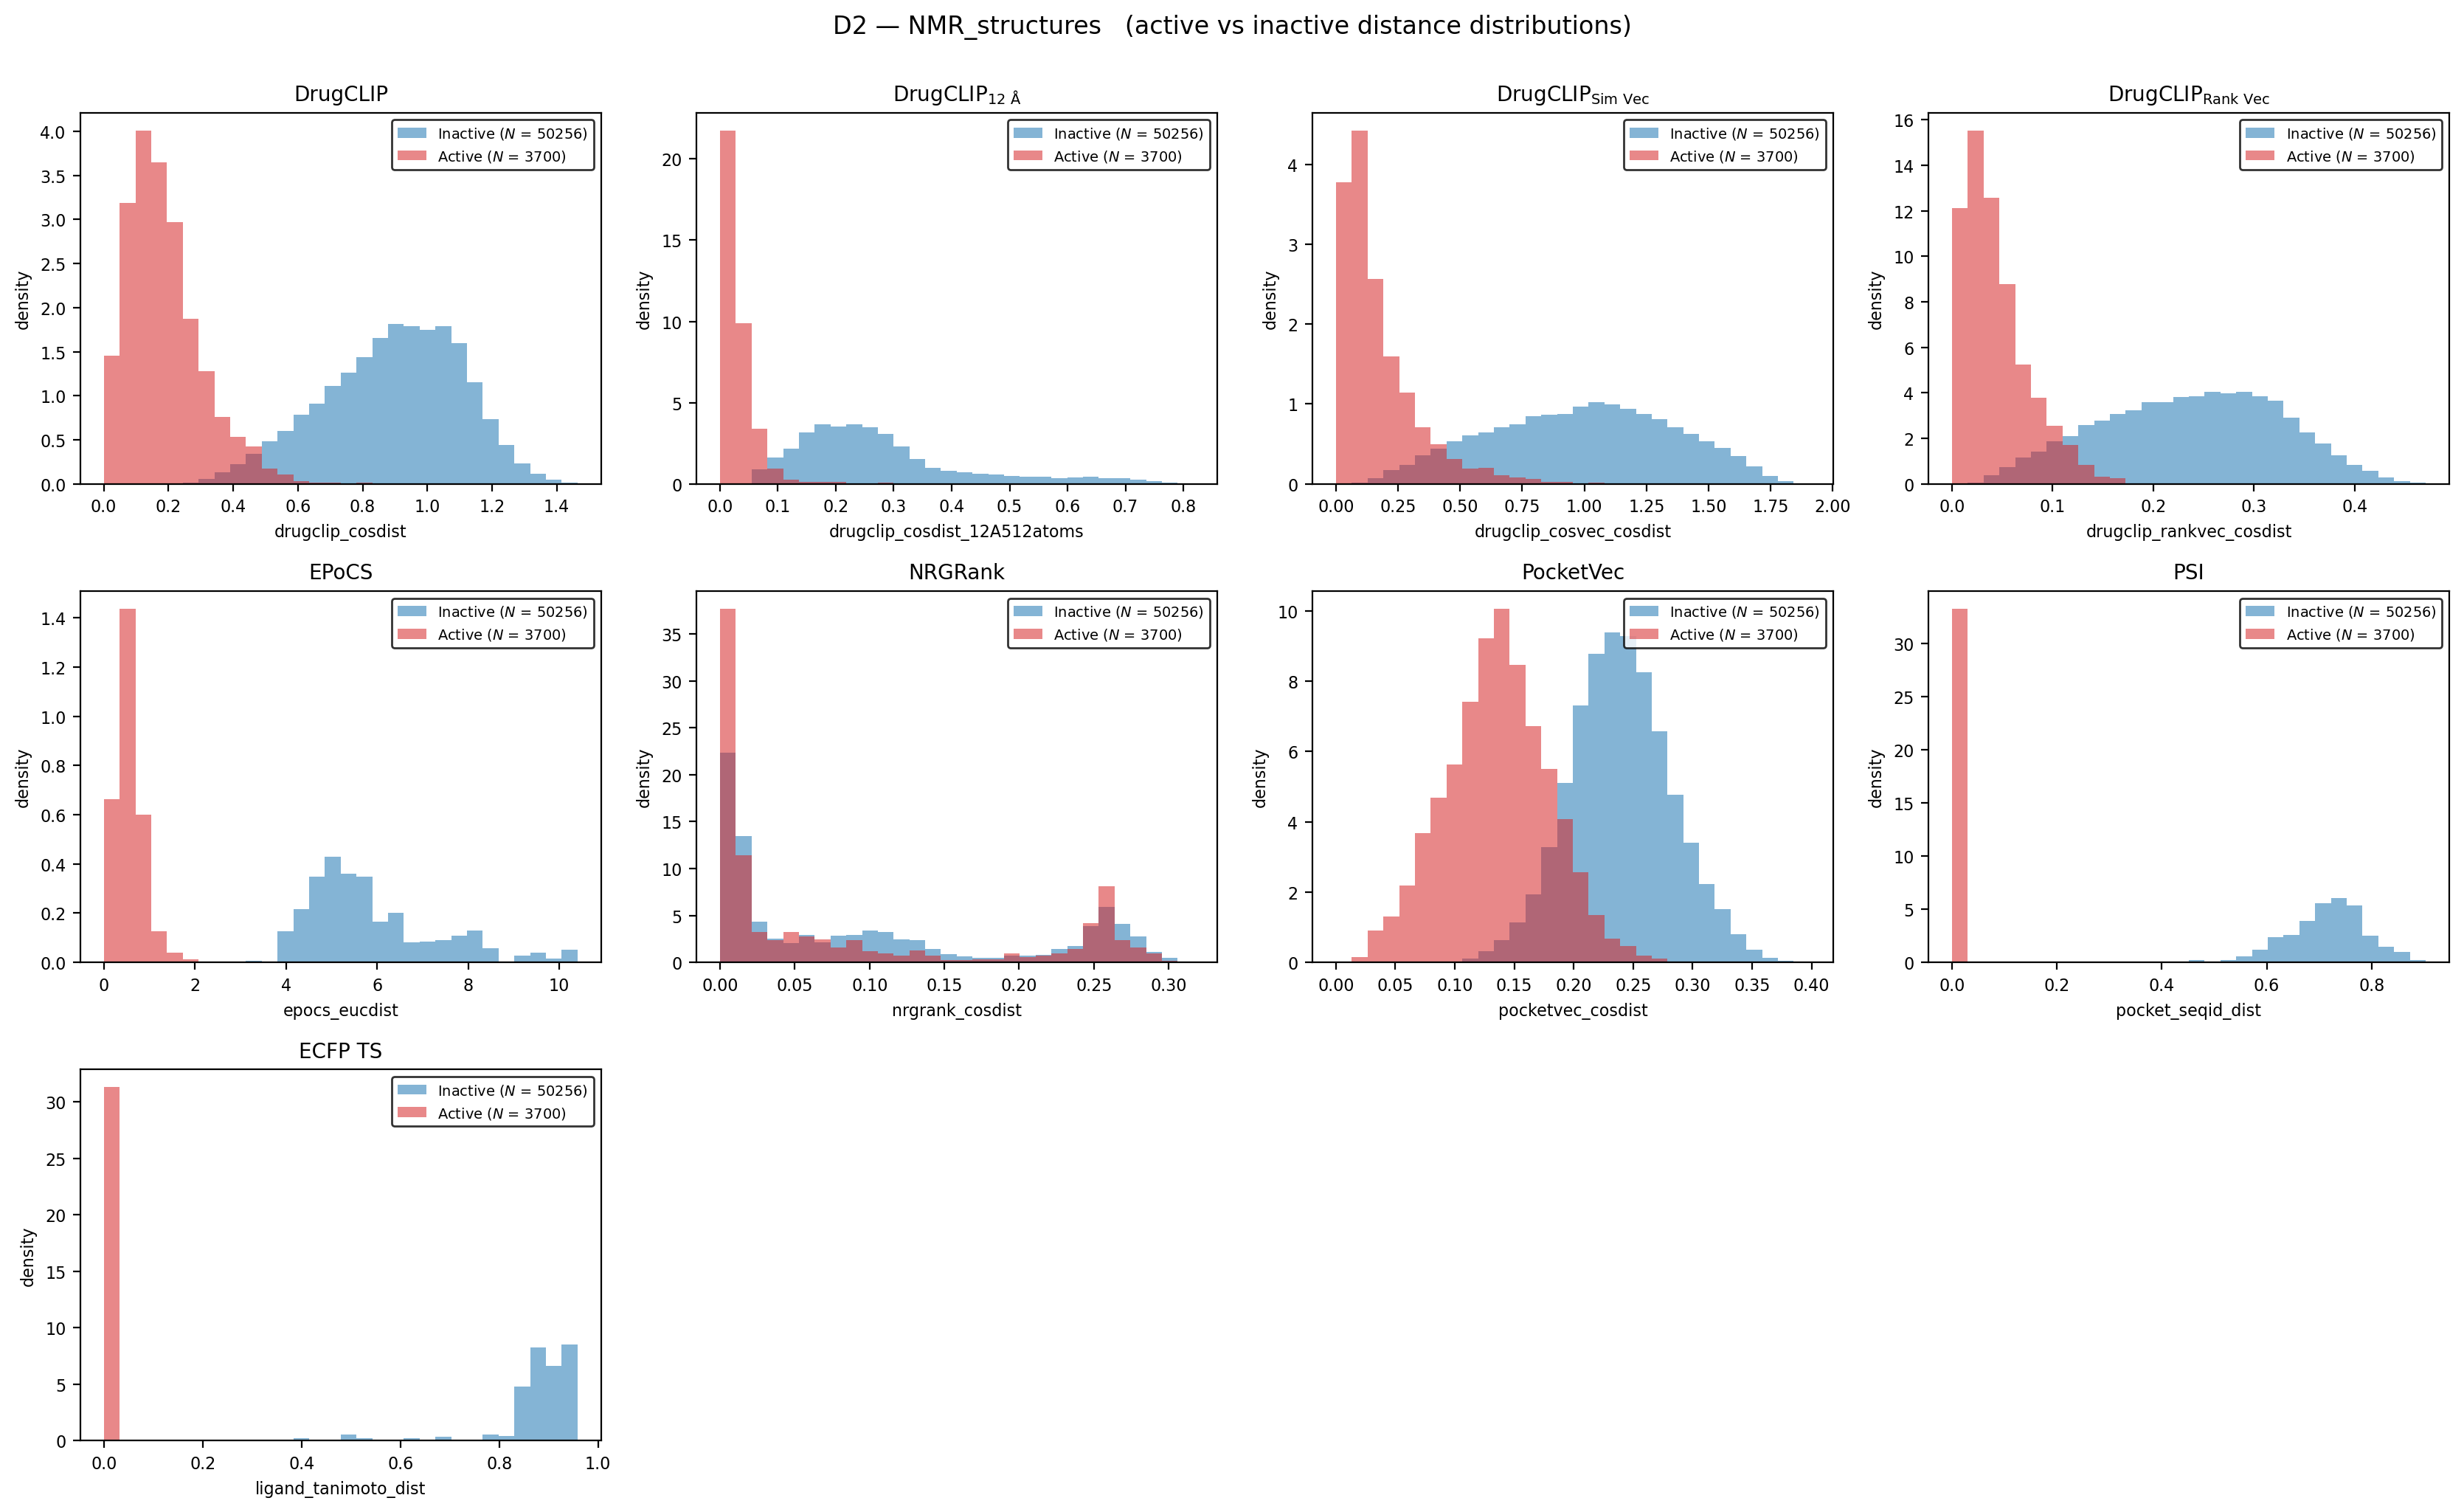

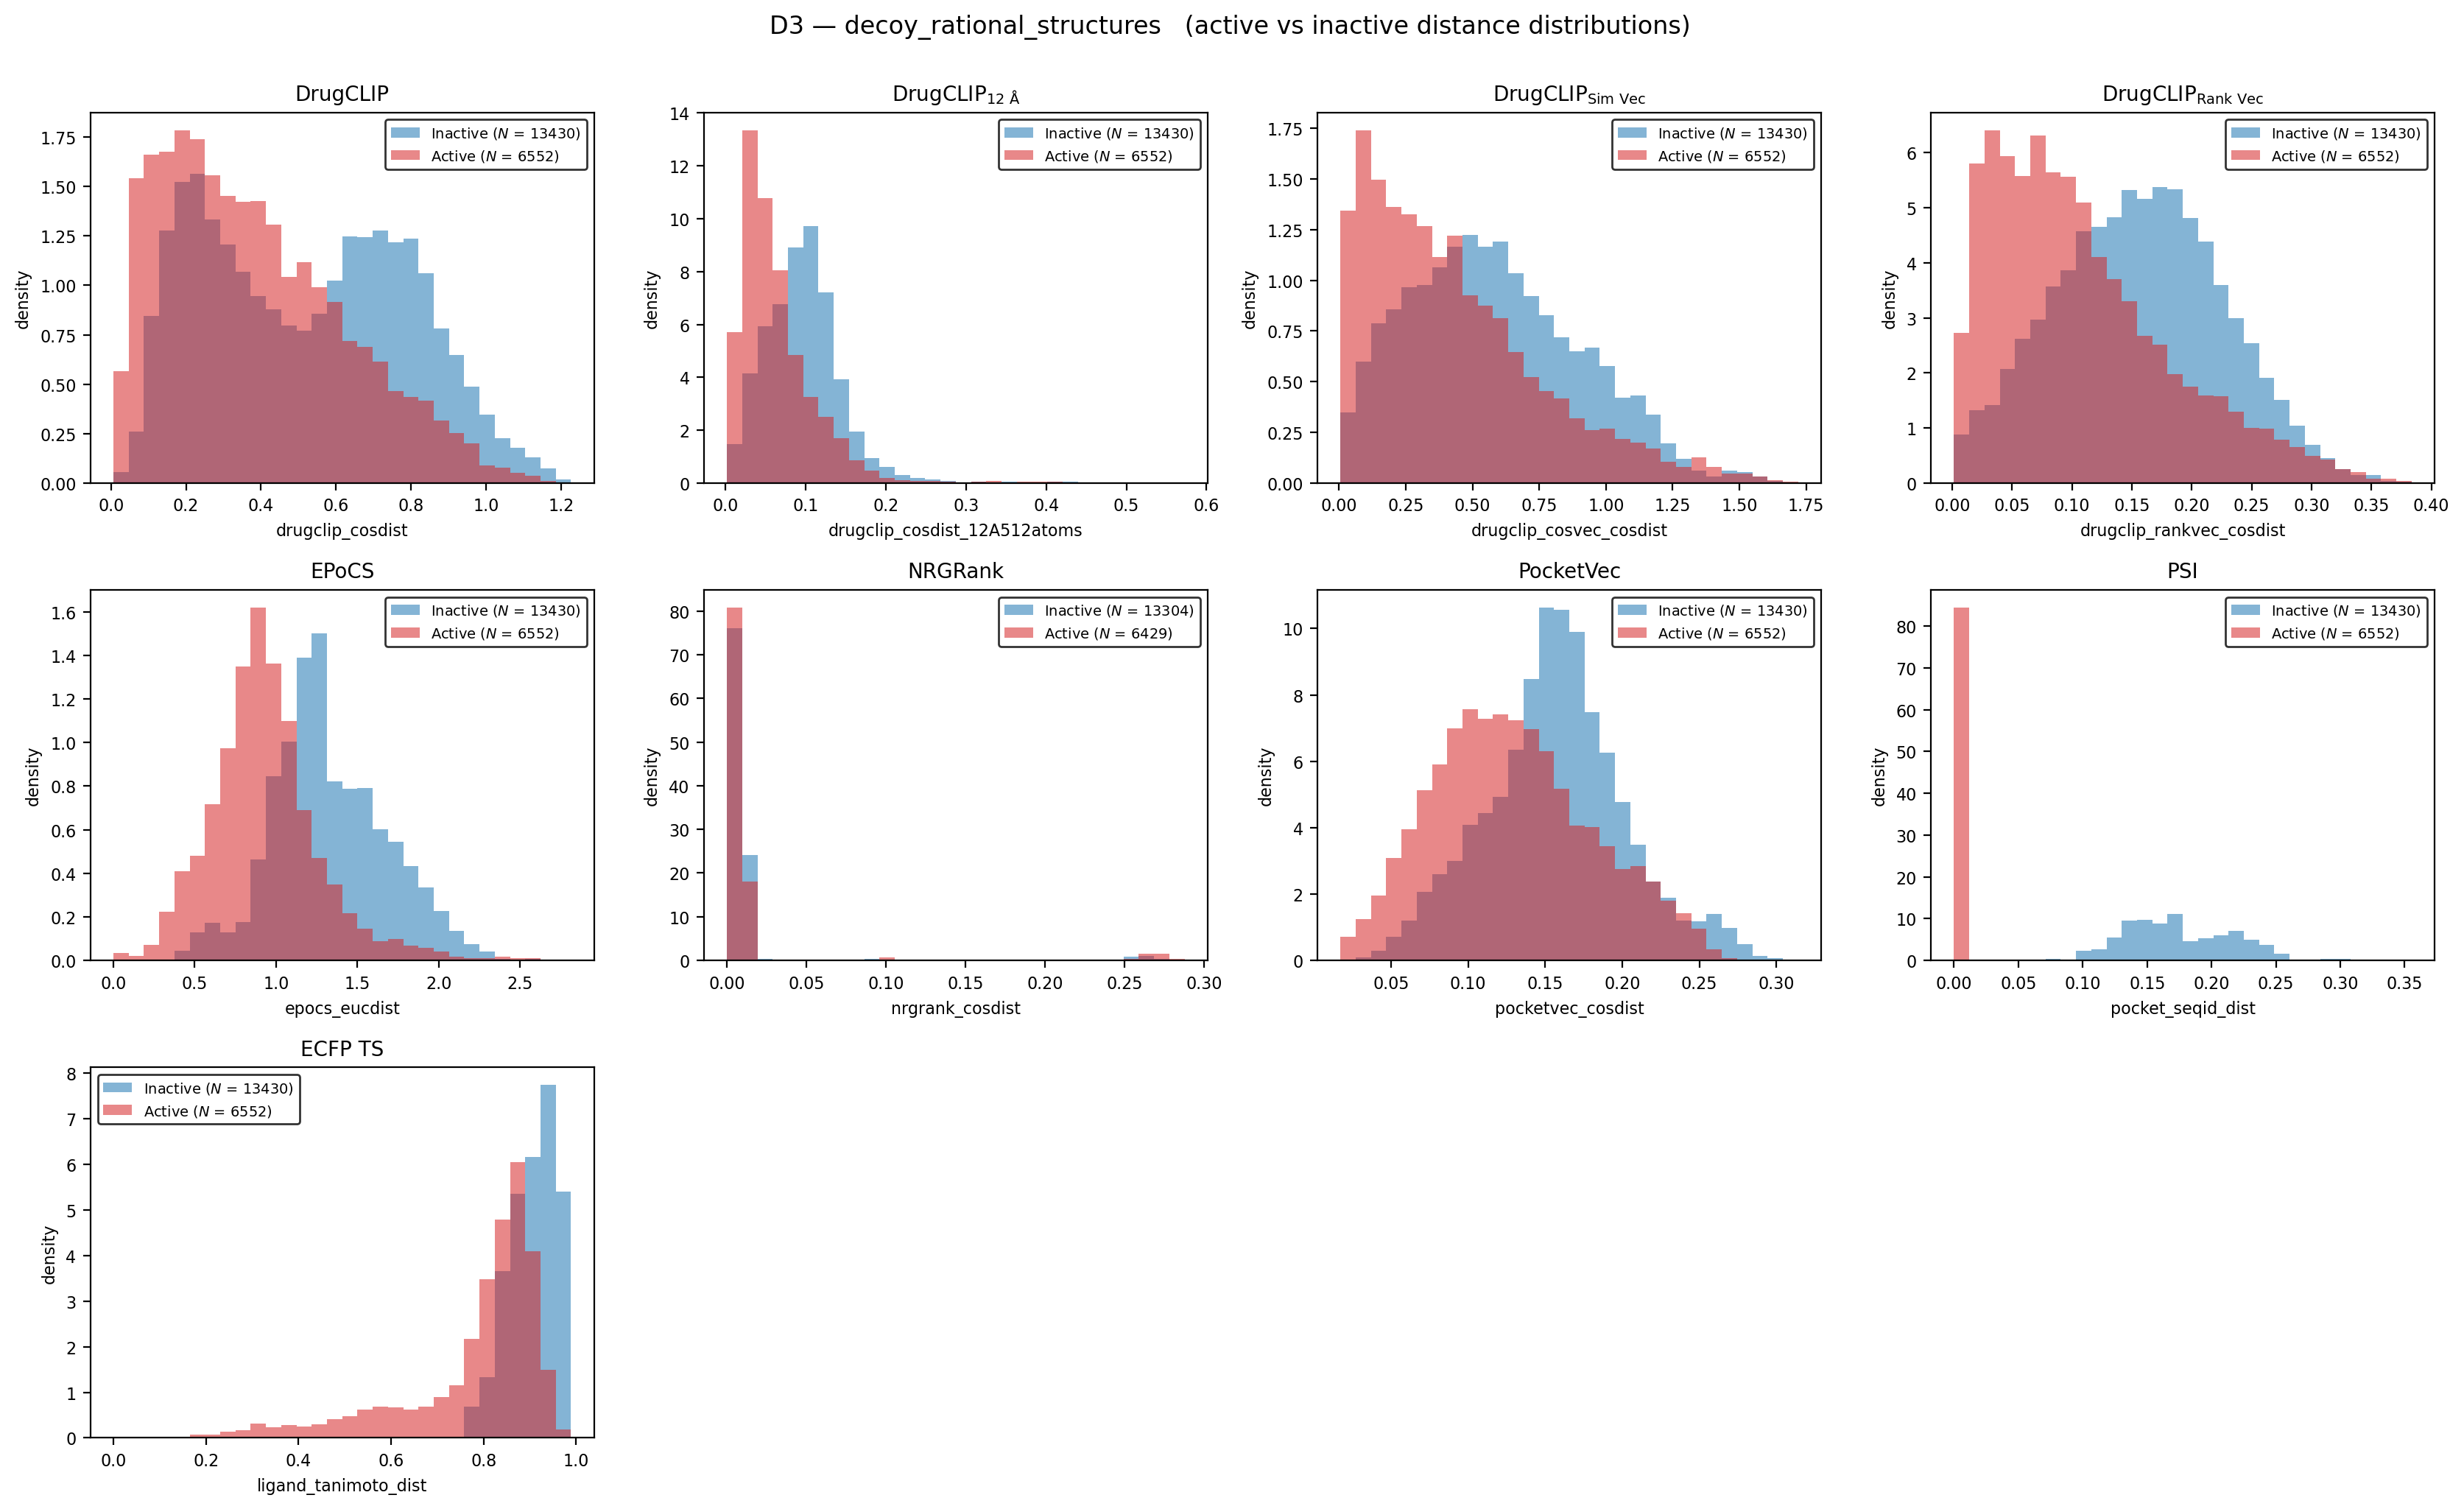

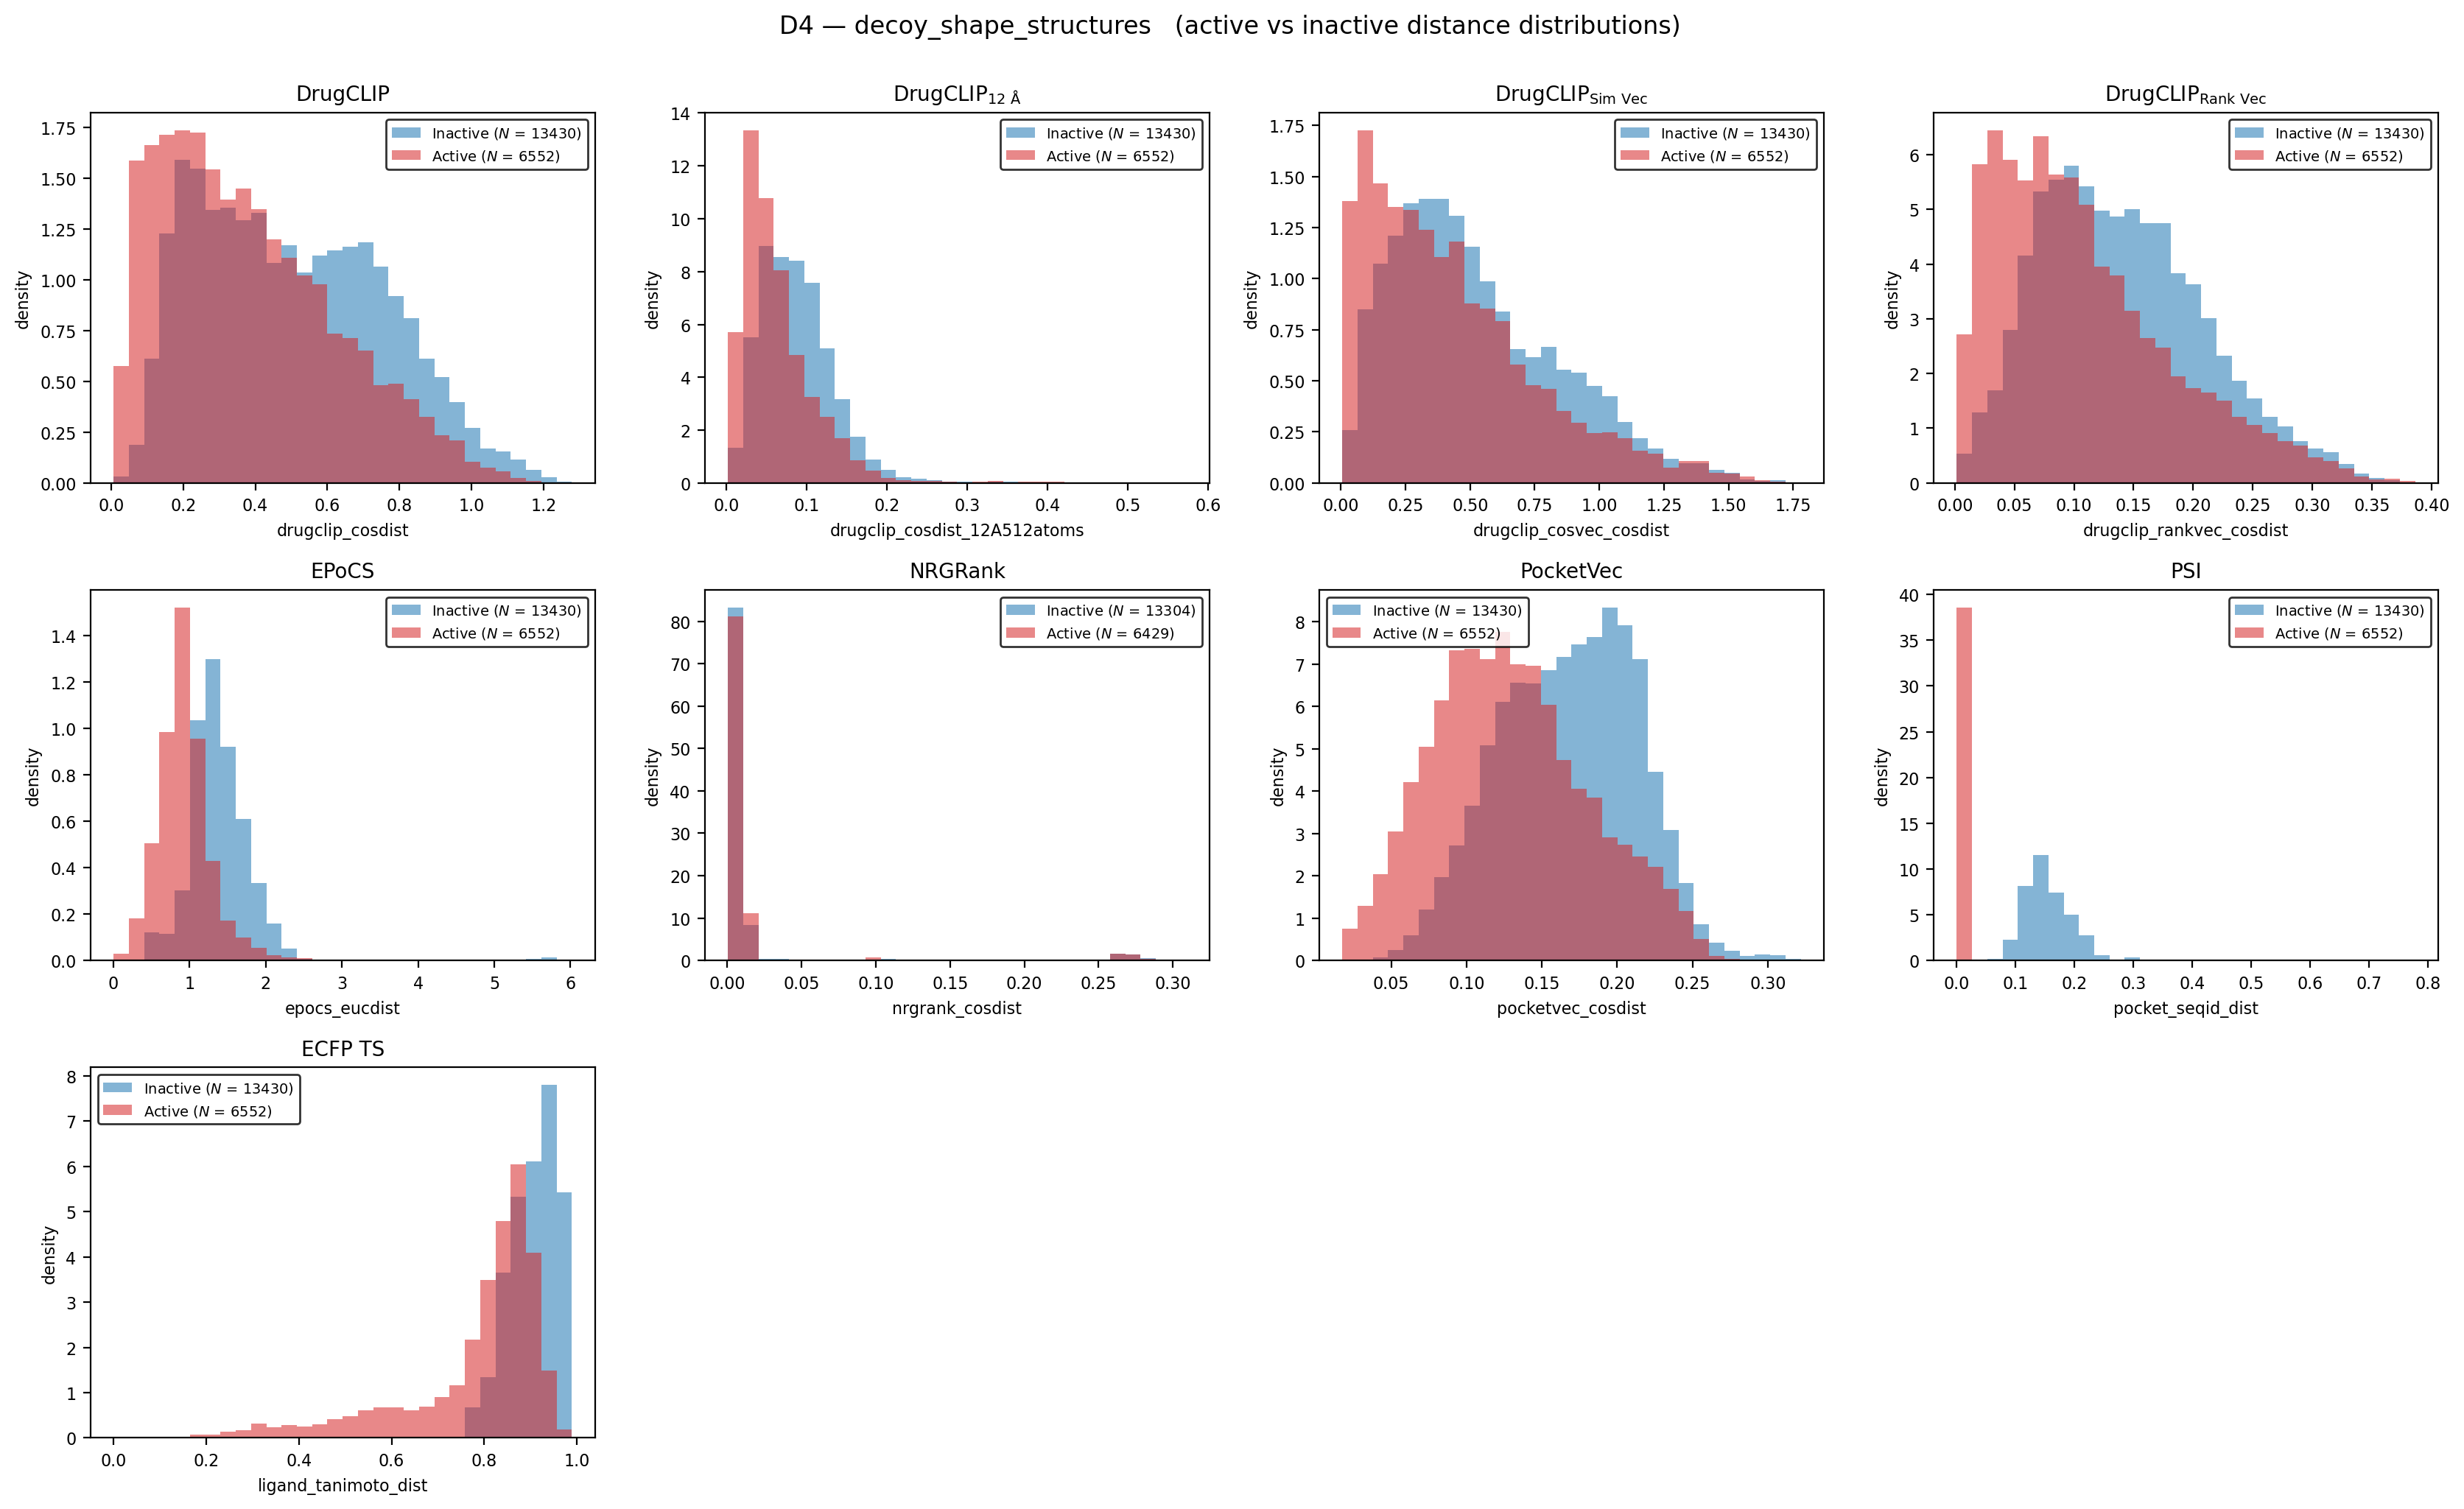

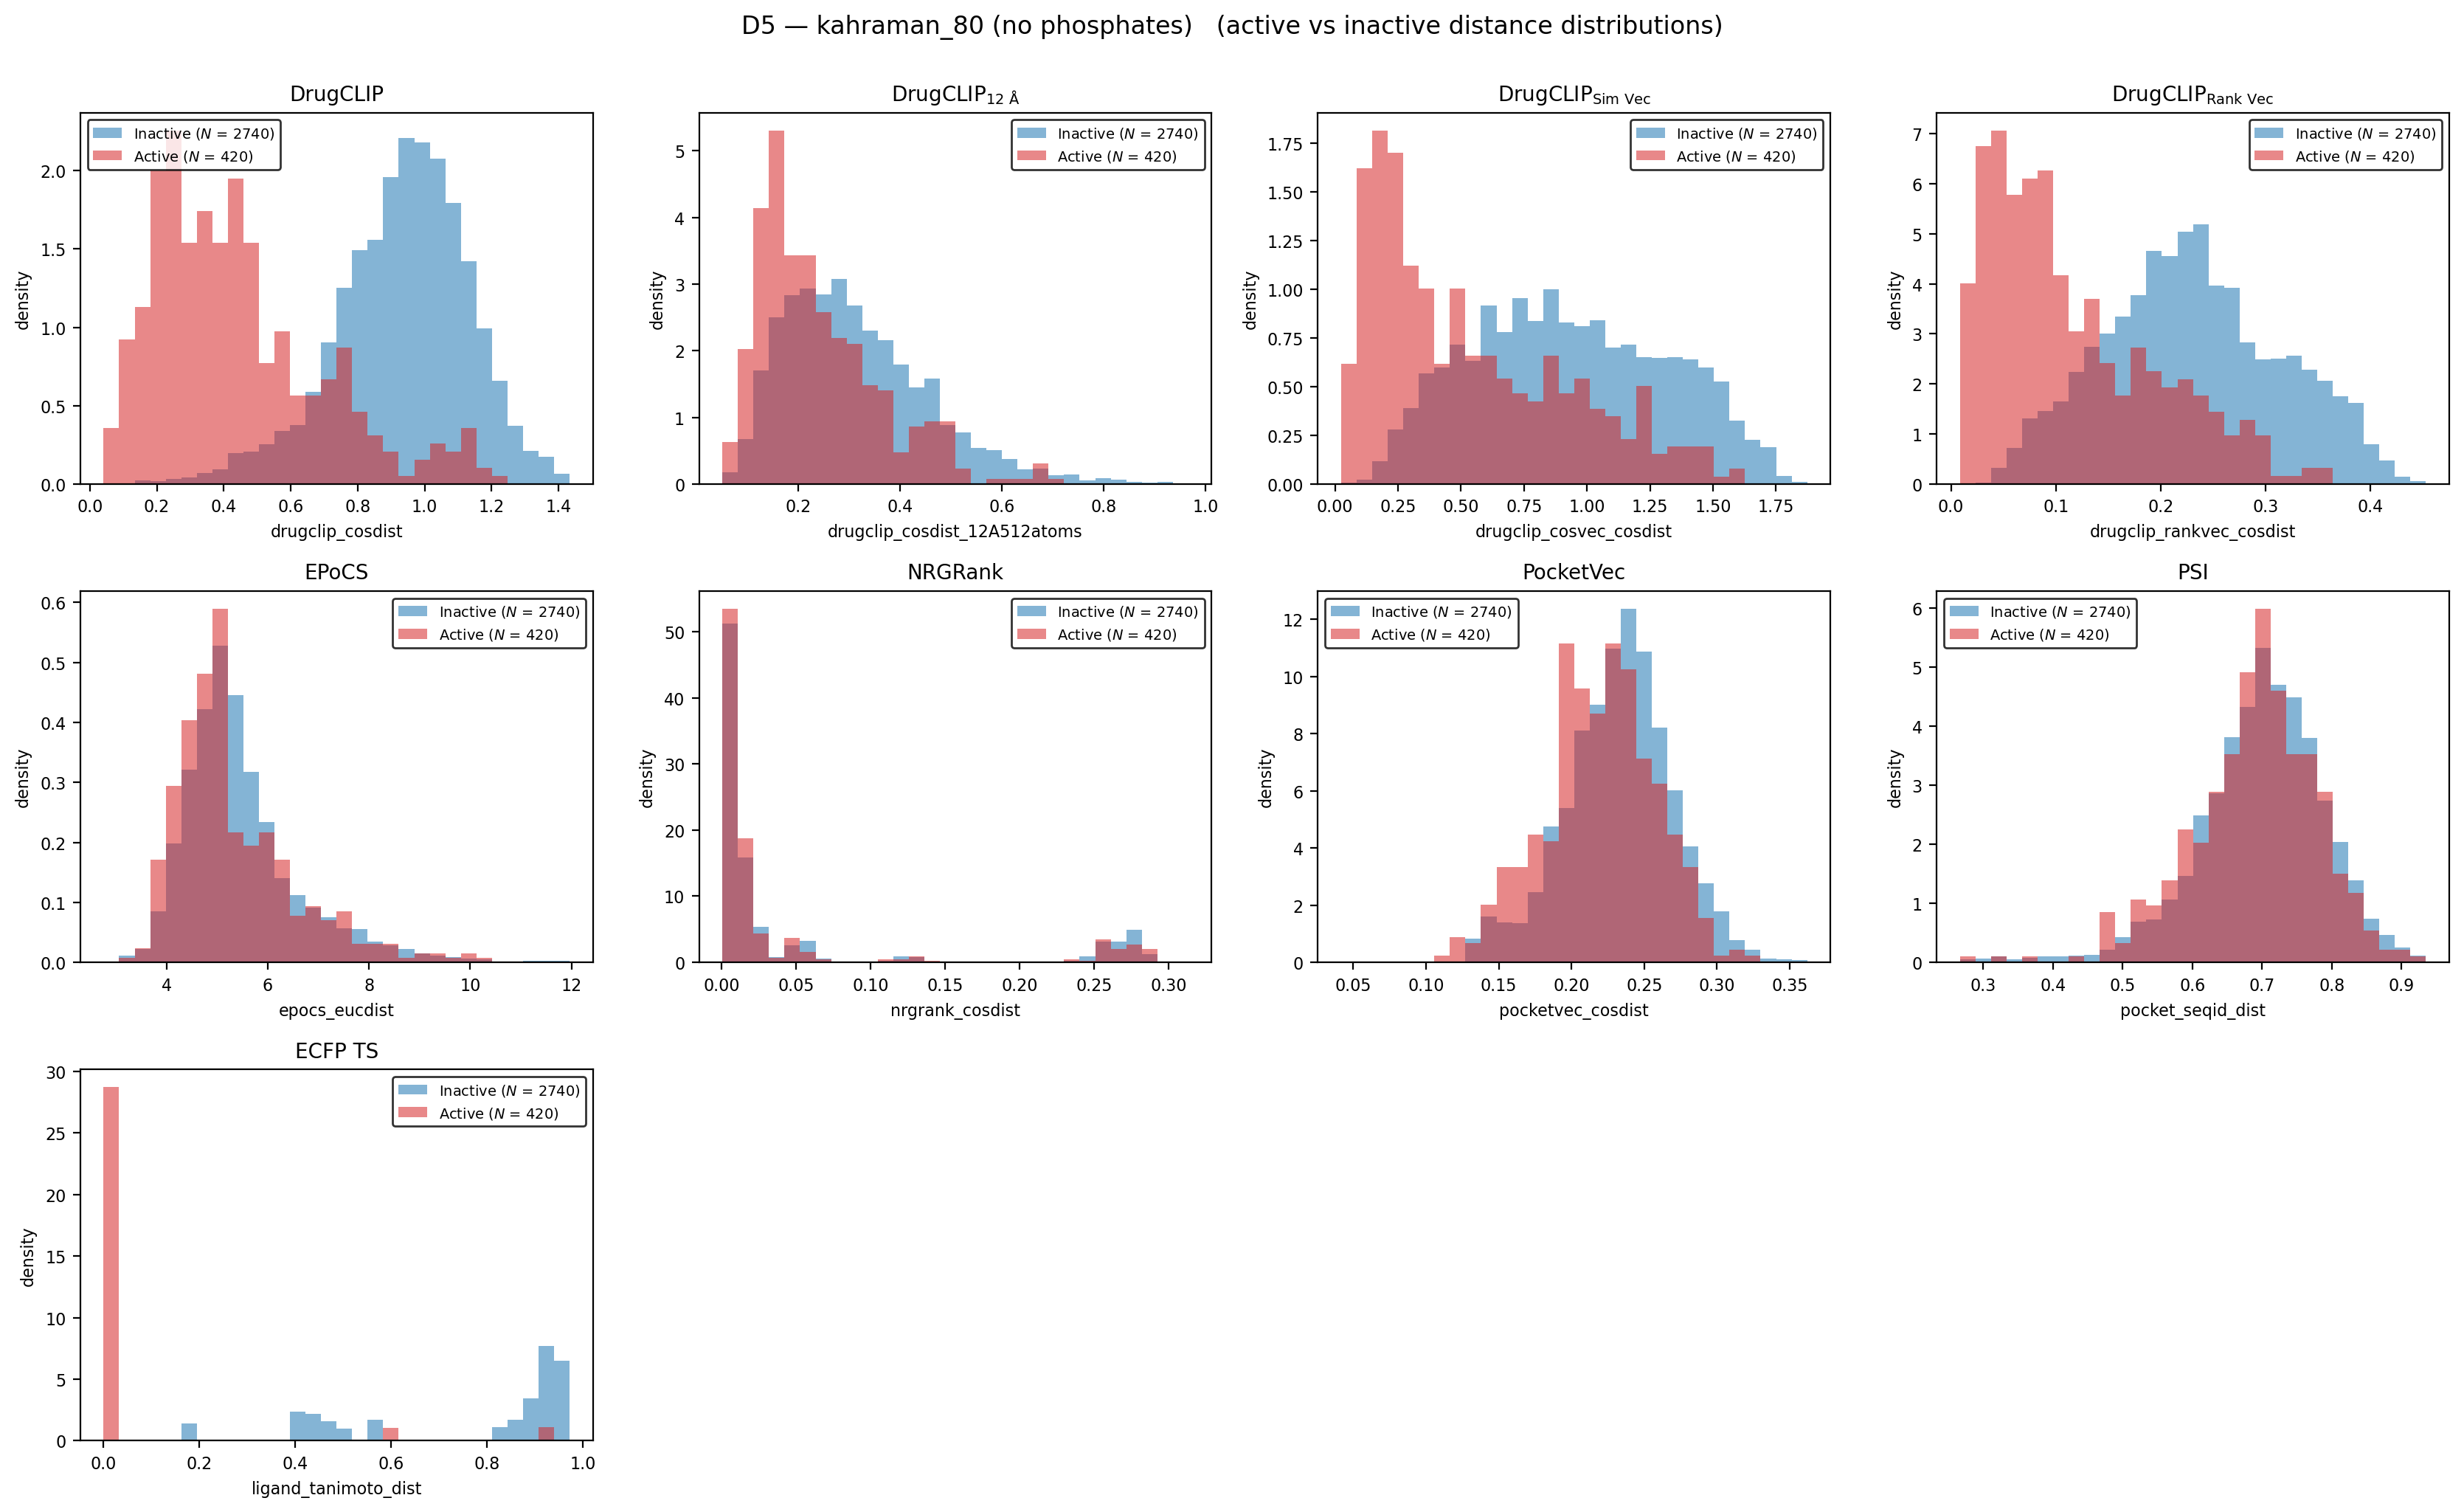

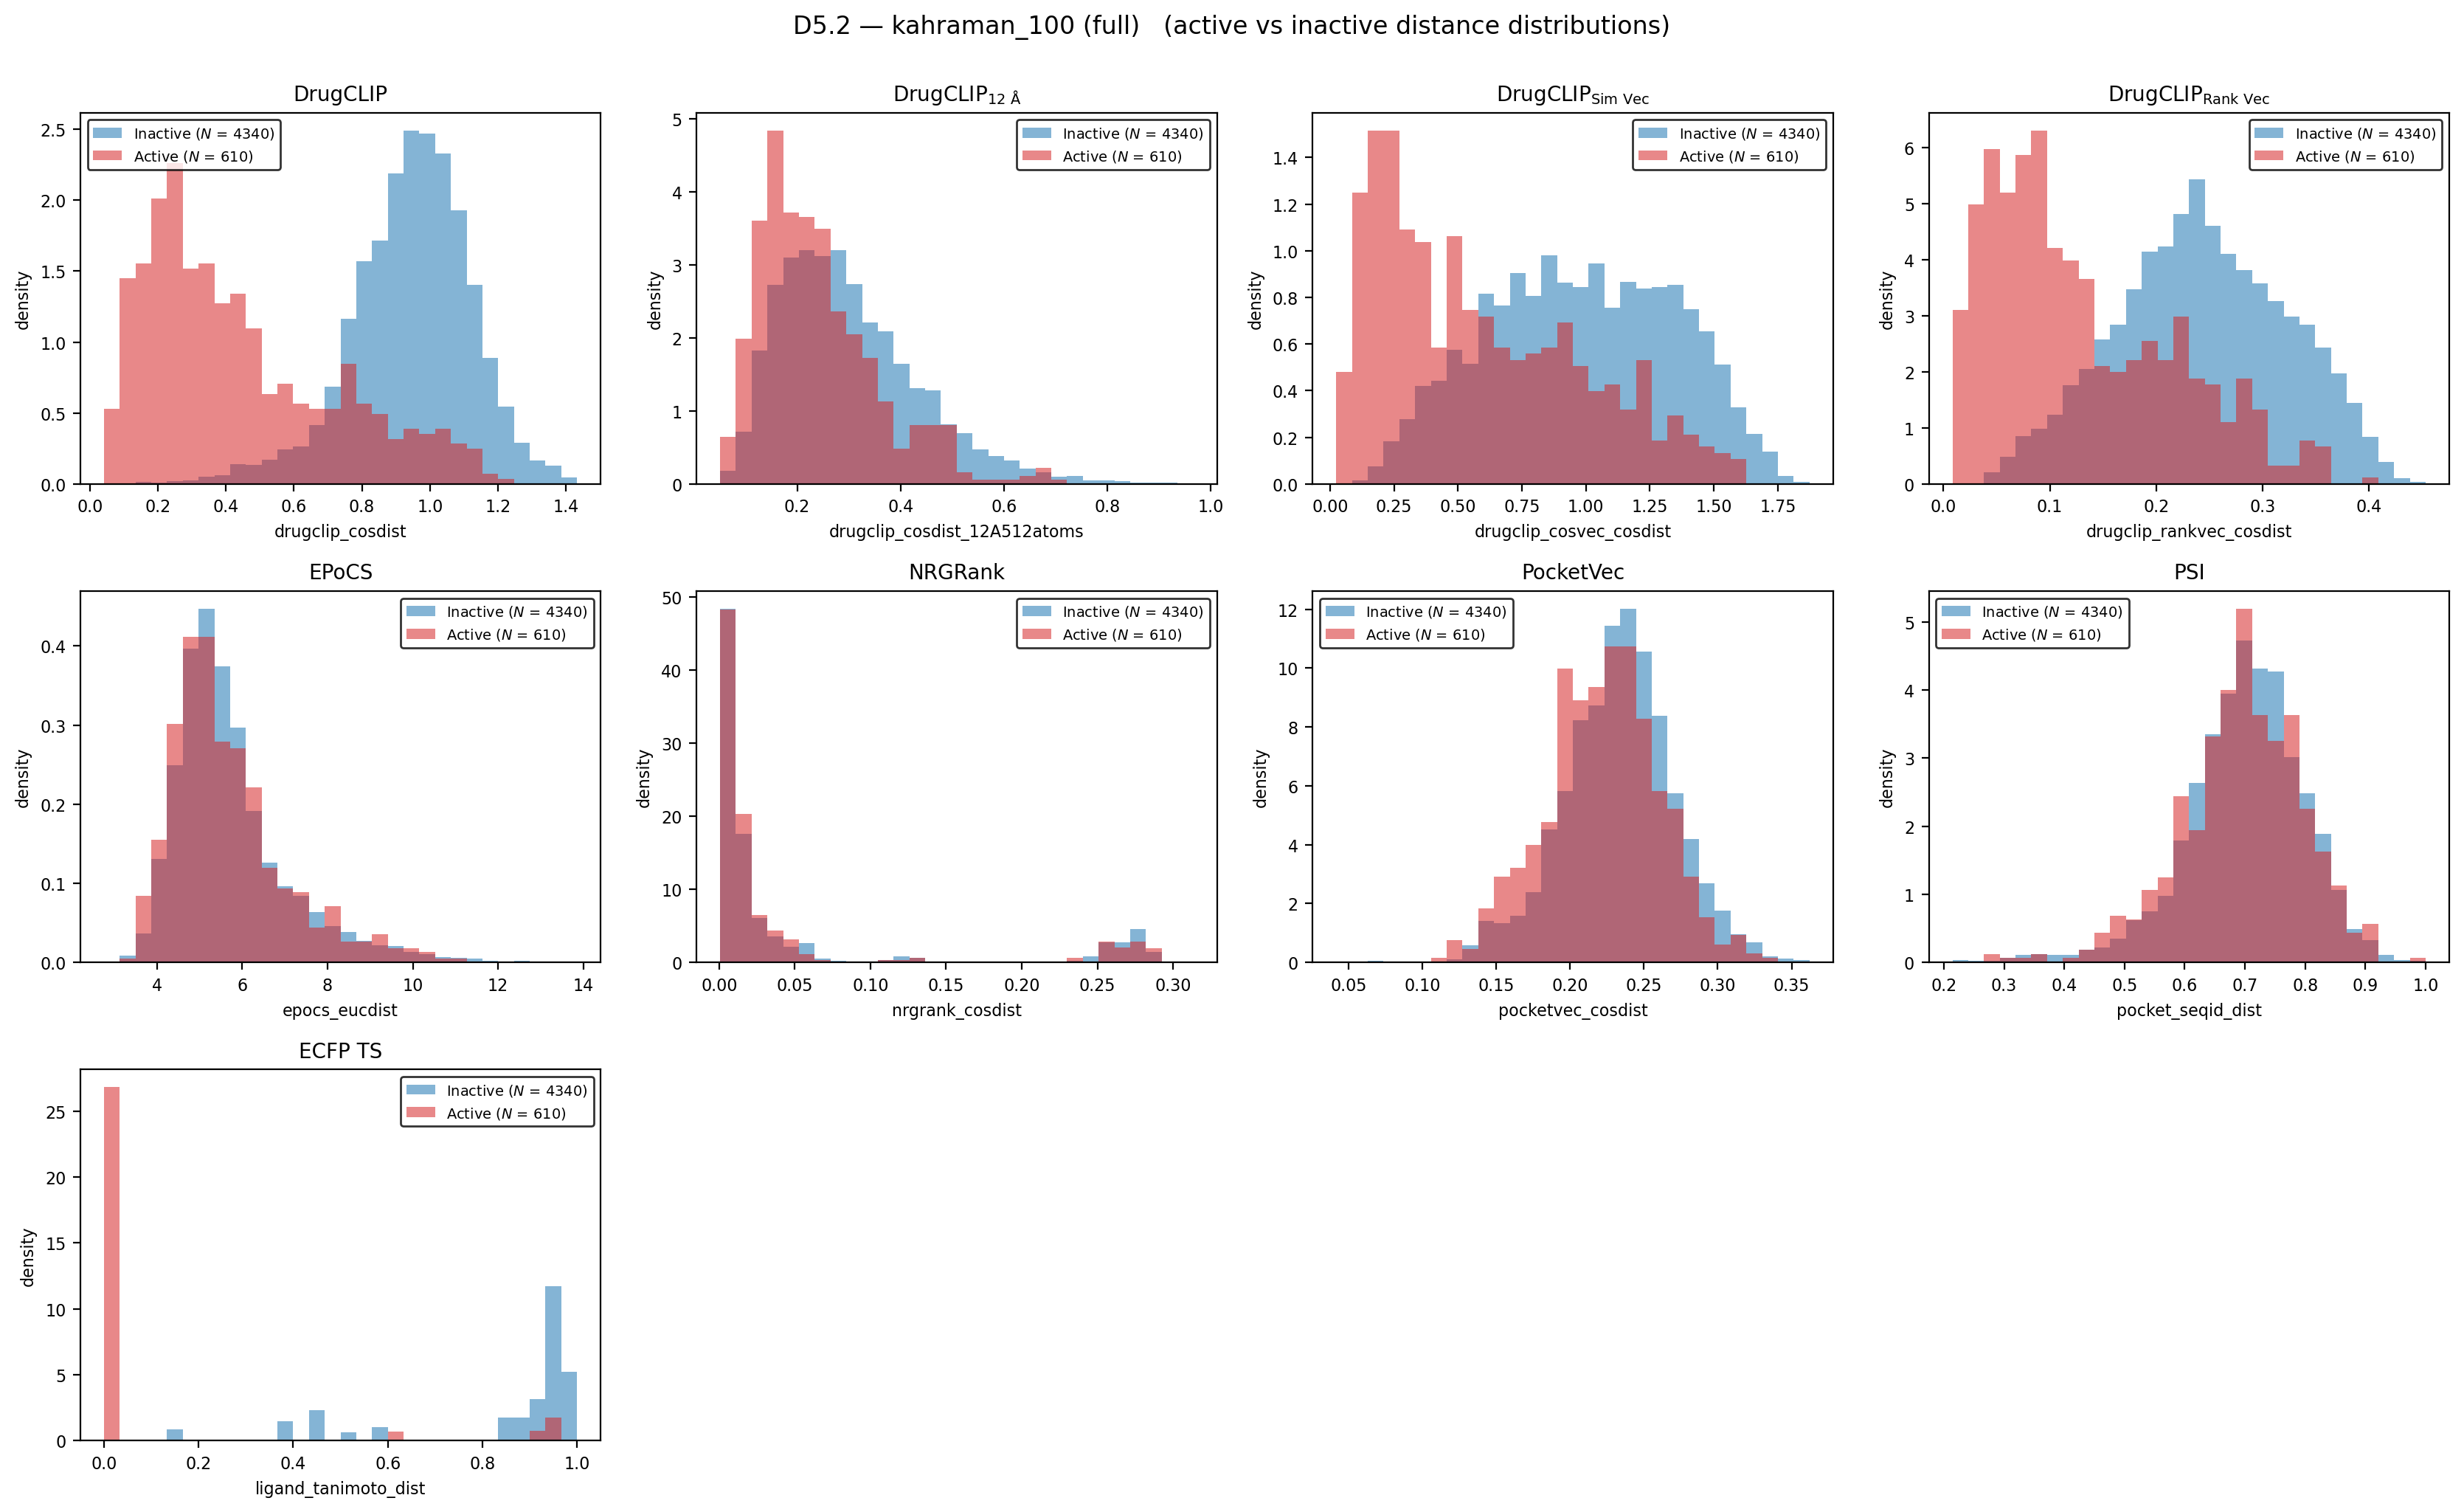

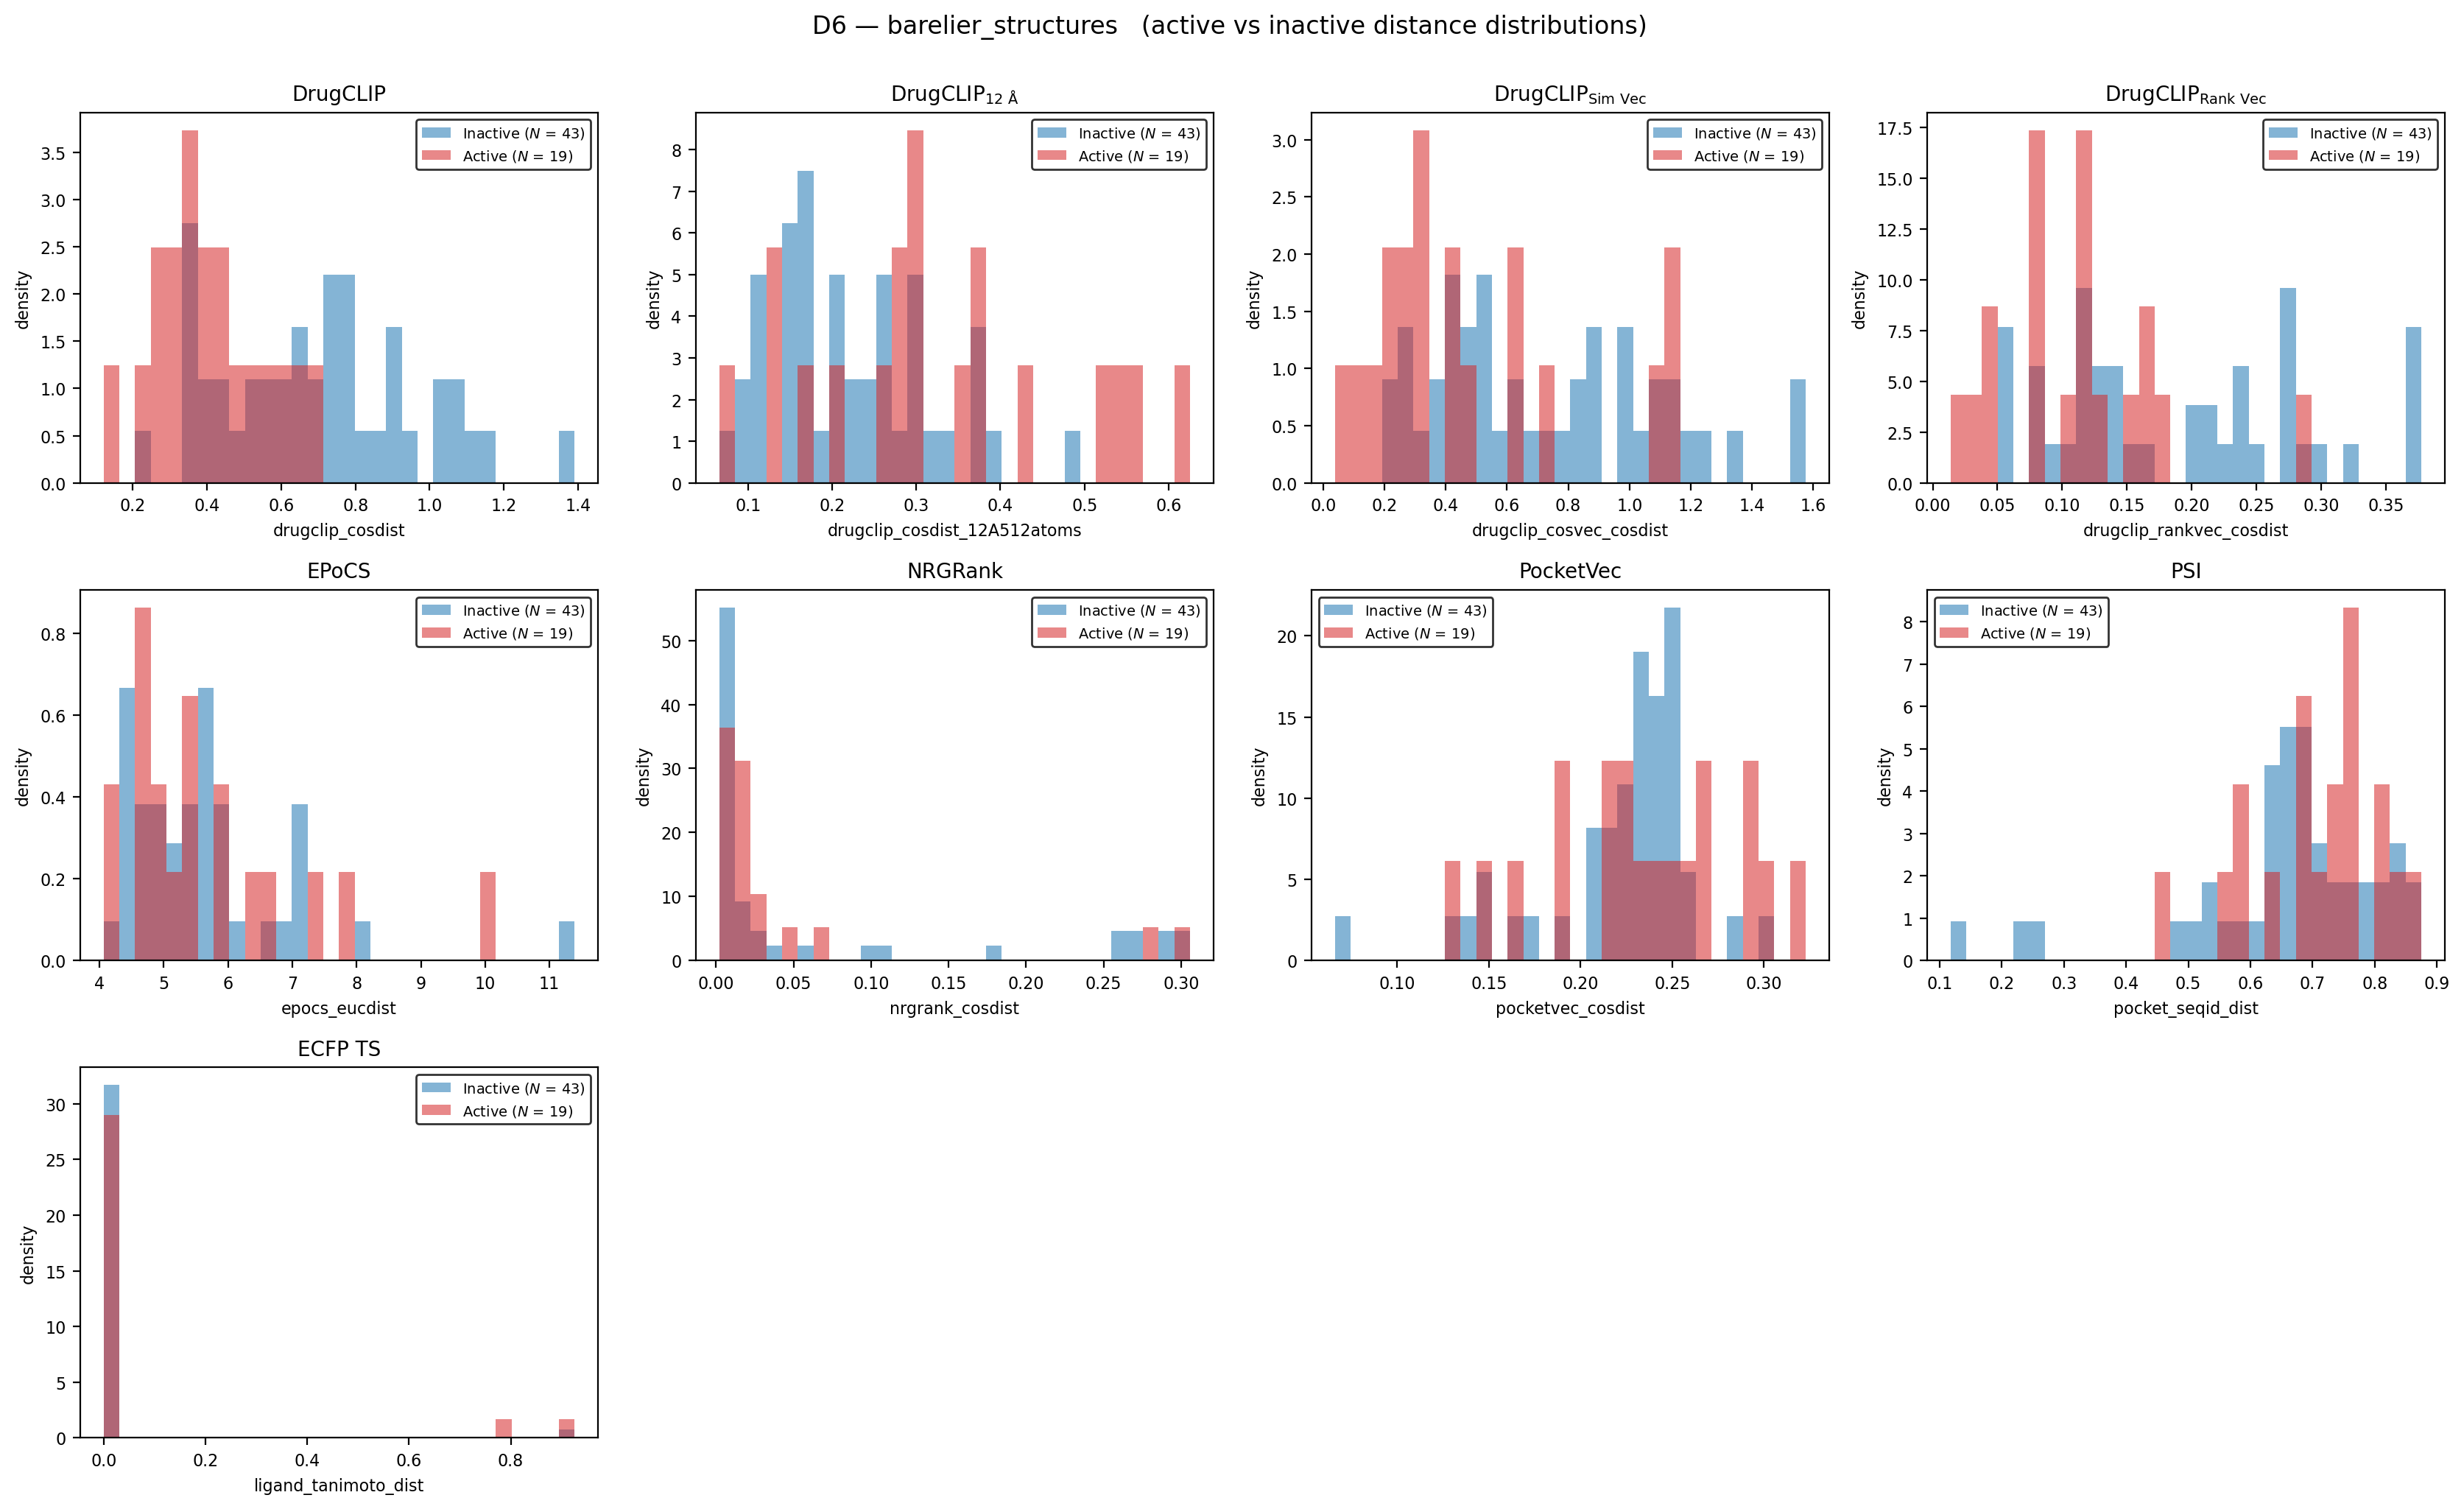

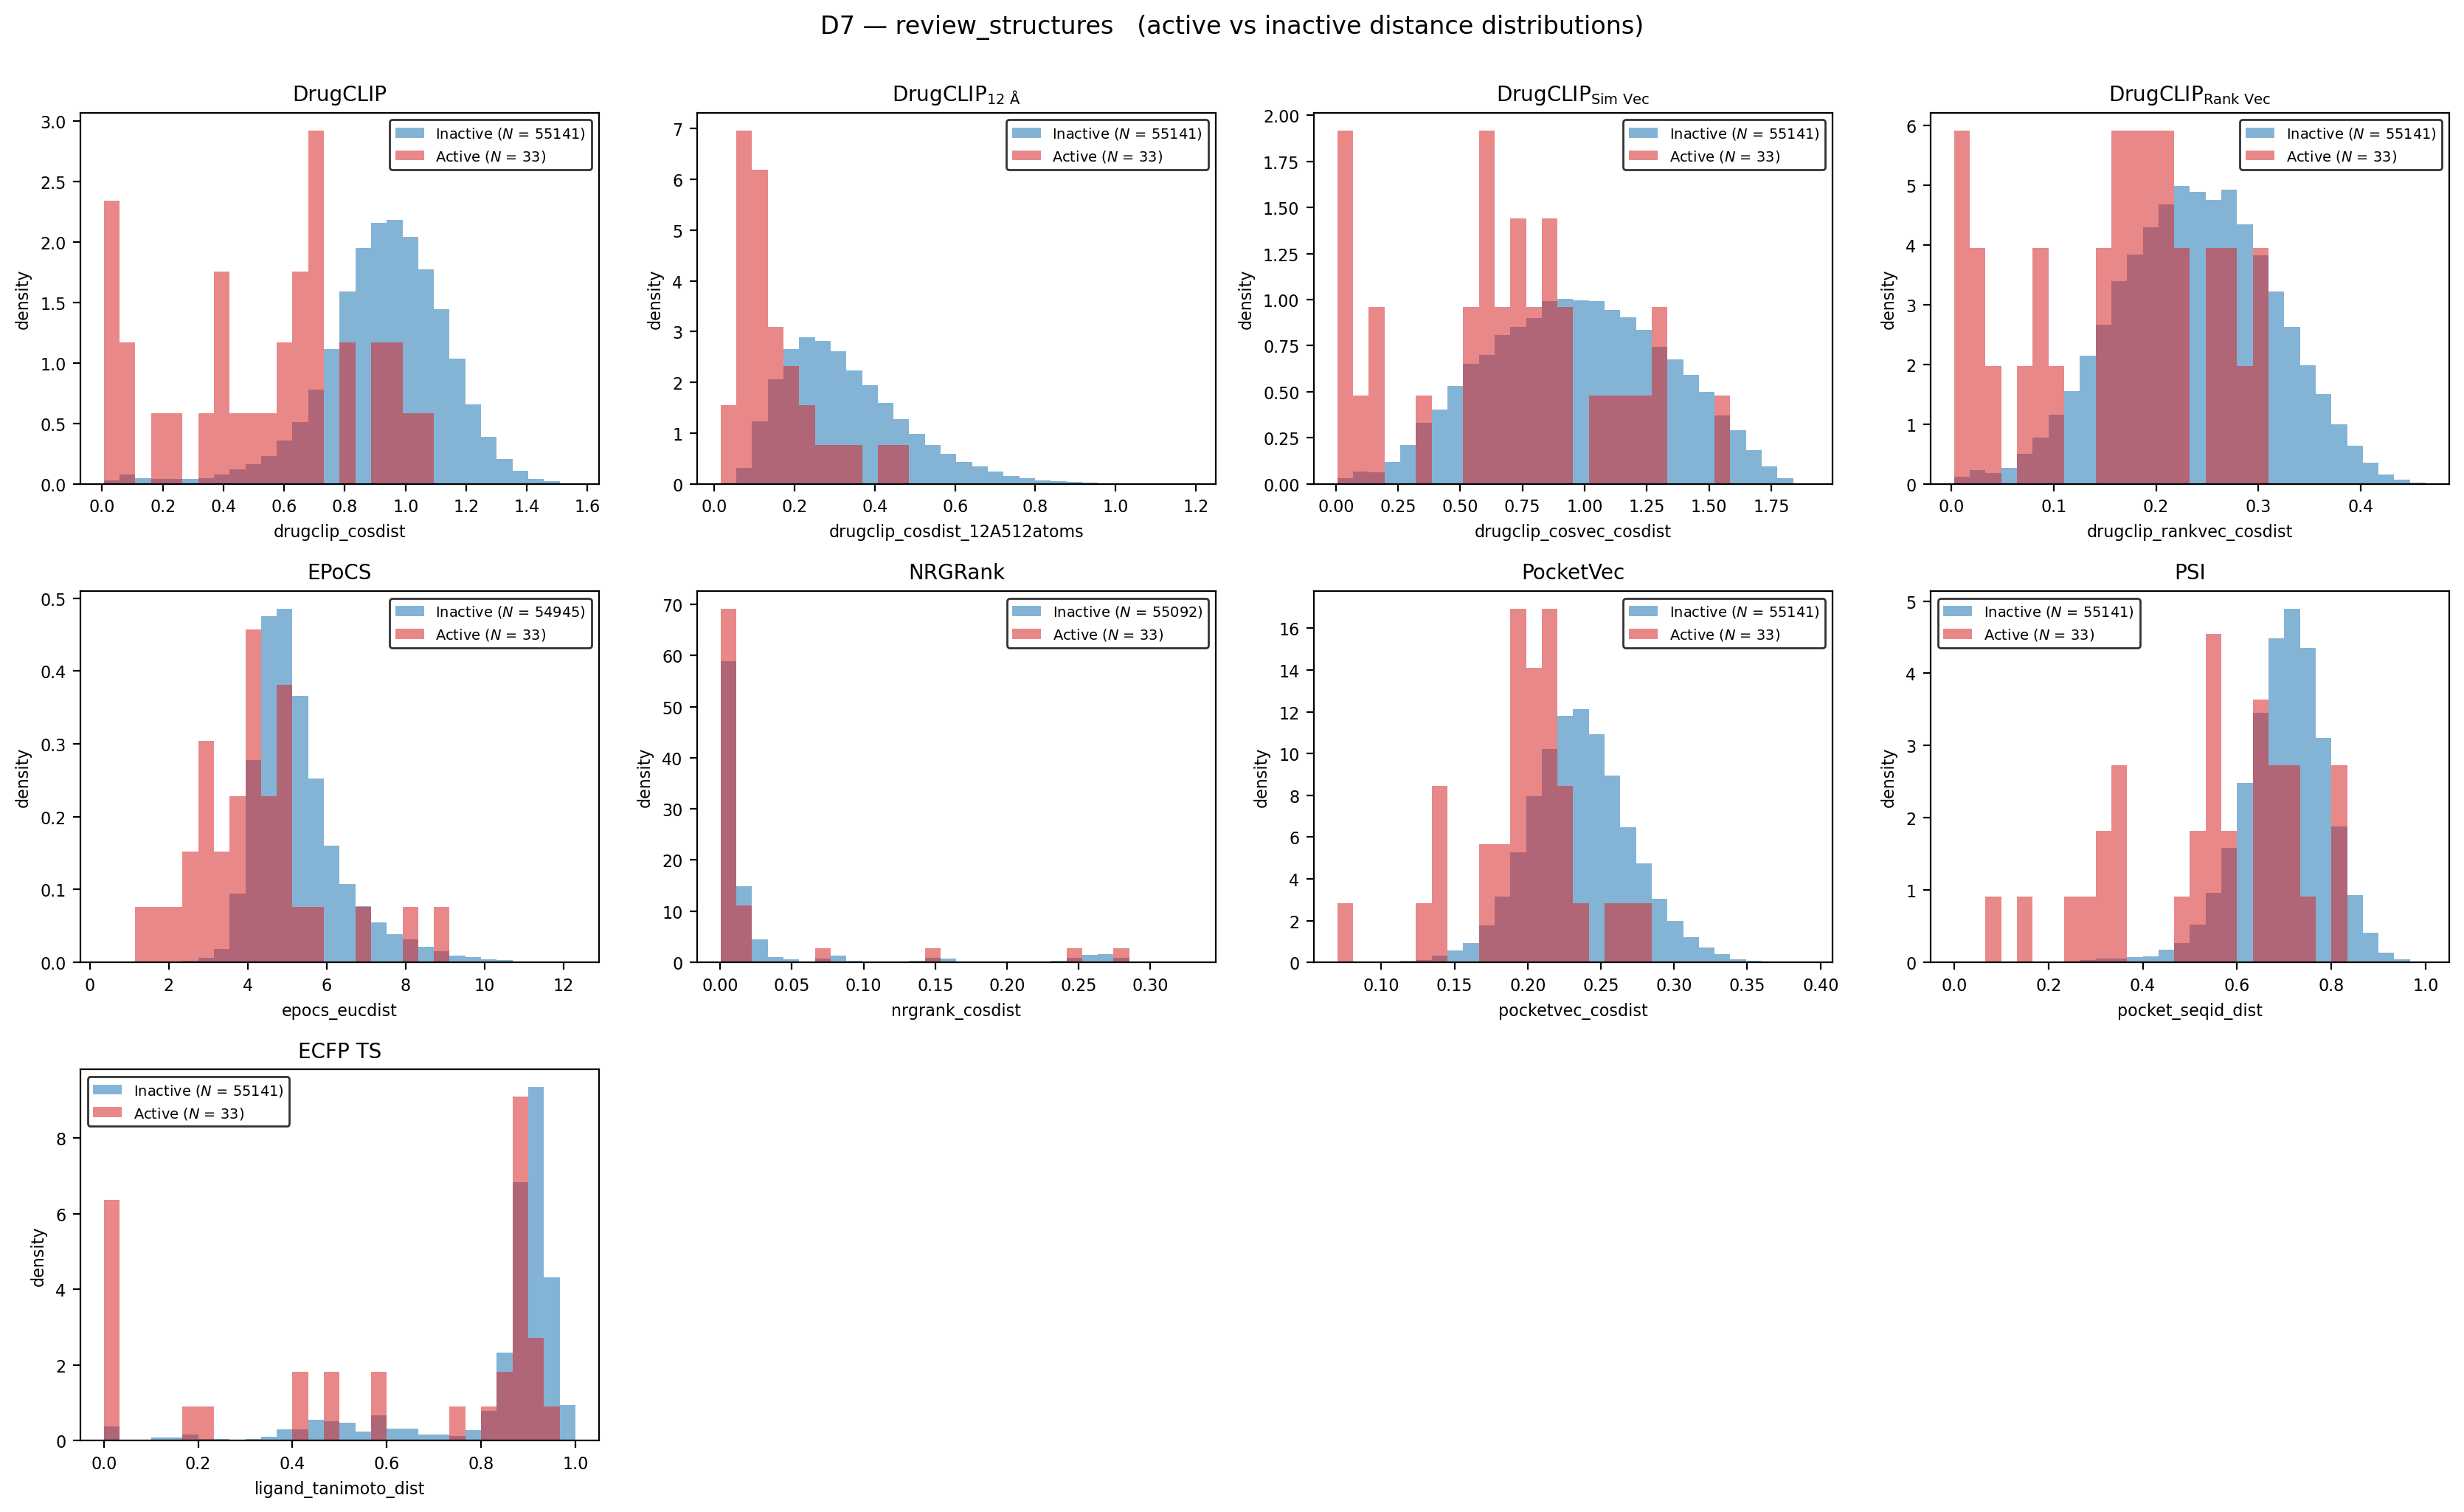

In [20]:
METHOD_DIST_COLS = {
    'pocketvec':            'pocketvec_cosdist',
    'nrgrank':              'nrgrank_cosdist',
    'drugclip':             'drugclip_cosdist',
    'drugclip_12A512atoms': 'drugclip_cosdist_12A512atoms',
    'drugclip_cosvec':      'drugclip_cosvec_cosdist',
    'drugclip_rankvec':     'drugclip_rankvec_cosdist',
    'epocs':                'epocs_eucdist',
    'pocket_seqid':         'pocket_seqid_dist',
    'ligand_tanimoto':      'ligand_tanimoto_dist',
}

ACTIVE_COLOR   = 'tab:red'
INACTIVE_COLOR = 'tab:blue'


def plot_distance_distributions(df: pd.DataFrame, dkey: str, bins: int = 30) -> None:
    df = deduplicate_pairs(df)

    panels = []
    for label, _ in PLOT_METHODS:
        col = METHOD_DIST_COLS.get(label)
        if col is None or col not in df.columns:
            continue
        d_act = pd.to_numeric(df.loc[df['lab'] == 'active',   col], errors='coerce').dropna()
        d_ina = pd.to_numeric(df.loc[df['lab'] == 'inactive', col], errors='coerce').dropna()
        if len(d_act) == 0 or len(d_ina) == 0:
            continue
        panels.append((label, col, d_act, d_ina))

    if not panels:
        return

    ncols = min(len(panels), 4)
    nrows = (len(panels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False, dpi=200)
    axes = axes.flatten()

    for ax, (label, col, d_act, d_ina) in zip(axes, panels):
        lo = float(min(d_act.min(), d_ina.min()))
        hi = float(max(d_act.max(), d_ina.max()))
        edges = np.linspace(lo, hi, bins + 1)
        ax.hist(d_ina, bins=edges, alpha=0.55, color=INACTIVE_COLOR, density=True,
                edgecolor='none', label=f'Inactive ($N$ = {len(d_ina)})')
        ax.hist(d_act, bins=edges, alpha=0.55, color=ACTIVE_COLOR, density=True,
                edgecolor='none', label=f'Active ($N$ = {len(d_act)})')
        ax.set_title(METHOD_LABELS[label], fontsize=10)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('density', fontsize=8)
        ax.legend(fontsize=7, loc='best', edgecolor='black')
        ax.tick_params(labelsize=8)

    for ax in axes[len(panels):]:
        ax.set_visible(False)

    fig.suptitle(f'{dkey} — {DATASETS[dkey]["pretty"]}   (active vs inactive distance distributions)',
                 fontsize=12, y=1.0)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'prospeccts_{dkey}_distance_distributions.png', dpi=600, bbox_inches='tight')
    plt.show()


for dkey, df in out.items():
    plot_distance_distributions(df, dkey)

## 13. Summary CSVs

Two flat exports for downstream use outside this notebook:

- **`prospeccts_roc_auc_summary.csv`** - ROC-AUC for every (dataset, method) pair, methods in the same order as the plot legends above (DrugCLIP variants, EPoCS, NRGRank, PocketVec, then the naive baselines - `same_protein`/`same_ligand` included here even though they aren't drawn on the curves).
- **`prospeccts_dataset_summary.csv`** - dataset composition: number of scored comparisons (de-duplicated, self-pairs dropped - same convention as every ROC/PR/threshold number above), number of unique pockets referenced, active/inactive counts, and the positive-class ratio.

In [21]:
def compute_auc_table(out: dict, methods) -> pd.DataFrame:
    """Full ROC-AUC table (every dataset x every method/baseline in `methods`,
    in that exact row order) - independent of what's actually drawn on the
    ROC curves above, so it includes same_protein/same_ligand too."""
    rows = {}
    for label, col in methods:
        row = {}
        for dkey, df in out.items():
            df = deduplicate_pairs(df)
            if col not in df.columns:
                row[dkey] = np.nan
                continue
            y = labels_to_int(df['lab'])
            s = pd.to_numeric(df[col], errors='coerce')
            mask = y.notna() & s.notna()
            if mask.sum() == 0 or y[mask].nunique() < 2:
                row[dkey] = np.nan
                continue
            row[dkey] = roc_auc_score(y[mask], s[mask])
        rows[label] = row
    return pd.DataFrame(rows).T.reindex(index=[label for label, _ in methods])


roc_auc_df = compute_auc_table(out, METHODS)
roc_auc_df.to_csv(RESULTS_DIR / 'prospeccts_roc_auc_summary.csv')
print(f'Saved -> {RESULTS_DIR / "prospeccts_roc_auc_summary.csv"}')
roc_auc_df

Saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_roc_auc_summary.csv


,D1,D1.2,D2,D3,D4,D5,D5.2,D6,D7
drugclip,0.951950,0.998536,0.997207,0.648229,0.638601,0.921339,0.913667,0.837209,0.851831
drugclip_12A512atoms,0.974782,0.998581,0.993088,0.723536,0.676579,0.663384,0.643460,0.301102,0.849058
drugclip_cosvec,0.838895,0.968598,0.980776,0.651204,0.599227,0.774685,0.770555,0.713586,0.687866
drugclip_rankvec,0.887012,0.981651,0.983146,0.700352,0.645944,0.840104,0.827889,0.739290,0.718801
epocs,1.000000,1.000000,1.000000,0.812151,0.838274,0.554460,0.521956,0.514076,0.756061
nrgrank,0.725800,0.788706,0.605706,0.616726,0.533561,0.519110,0.505708,0.552020,0.638249
pocketvec,0.965459,0.997300,0.957214,0.662588,0.712302,0.601641,0.584168,0.441860,0.773838
same_protein,0.664606,0.867347,1.000000,0.664606,0.664606,0.500000,0.500000,0.500000,0.499964
same_ligand,0.499978,0.500000,0.988649,0.500000,0.500000,0.965476,0.946721,0.470624,0.600992
pocket_seqid,1.000000,1.000000,1.000000,1.000000,1.000000,0.533010,0.518148,0.406977,0.750881


In [22]:
def dataset_summary(out: dict) -> pd.DataFrame:
    rows = []
    for dkey, df in out.items():
        df = deduplicate_pairs(df)
        y = labels_to_int(df['lab'])
        n_active = int((y == 1).sum())
        n_inactive = int((y == 0).sum())
        n_total = len(df)
        n_pockets = len(set(df['p1']) | set(df['p2']))
        rows.append({
            'dataset': dkey,
            'pretty_name': DATASETS[dkey]['pretty'],
            'n_comparisons': n_total,
            'n_unique_pockets': n_pockets,
            'n_active': n_active,
            'n_inactive': n_inactive,
            'positive_ratio': n_active / n_total if n_total else float('nan'),
        })
    return pd.DataFrame(rows).set_index('dataset')


dataset_summary_df = dataset_summary(out)
dataset_summary_df.to_csv(RESULTS_DIR / 'prospeccts_dataset_summary.csv')
print(f'Saved -> {RESULTS_DIR / "prospeccts_dataset_summary.csv"}')
dataset_summary_df

Saved -> /Users/jsutges/Documents/POCKET_MATCHING_BENCHMARK/RESULTS/prospeccts_dataset_summary.csv


,pretty_name,n_comparisons,n_unique_pockets,n_active,n_inactive,positive_ratio
dataset,,,,,,
D1,identical_structures,52975,326,6552,46423,0.123681
D1.2,identical_structures_similar_ligands,990,45,98,892,0.098990
D2,NMR_structures,53956,329,3700,50256,0.068574
D3,decoy_rational_structures,19982,652,6552,13430,0.327895
D4,decoy_shape_structures,19982,652,6552,13430,0.327895
D5,kahraman_80 (no phosphates),3160,80,420,2740,0.132911
D5.2,kahraman_100 (full),4950,100,610,4340,0.123232
D6,barelier_structures,62,115,19,43,0.306452
D7,review_structures,55174,1151,33,55141,0.000598
